In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")

import warnings
warnings.filterwarnings("ignore")

ROOT = "."

def print_time():
    print(f"Model: {MODEL}")
    print("Forward:")
    print("\n".join(list(map(lambda x: f"  {x}", list(f["time"])))))
    print("Backward:")
    print("\n".join(list(map(lambda x: f"  {x}", list(b["time"])))))

## AlexNet

Model: AlexNet
Forward:
  17.63614204712212
  19.555042572319508
  15.917888721451163
  16.054538460448384
  19.4459368288517
Backward:
  20.57958122342825
  2.3122658021748066
  73.7308772932738
  65.27684179134667
  126.44263030961156


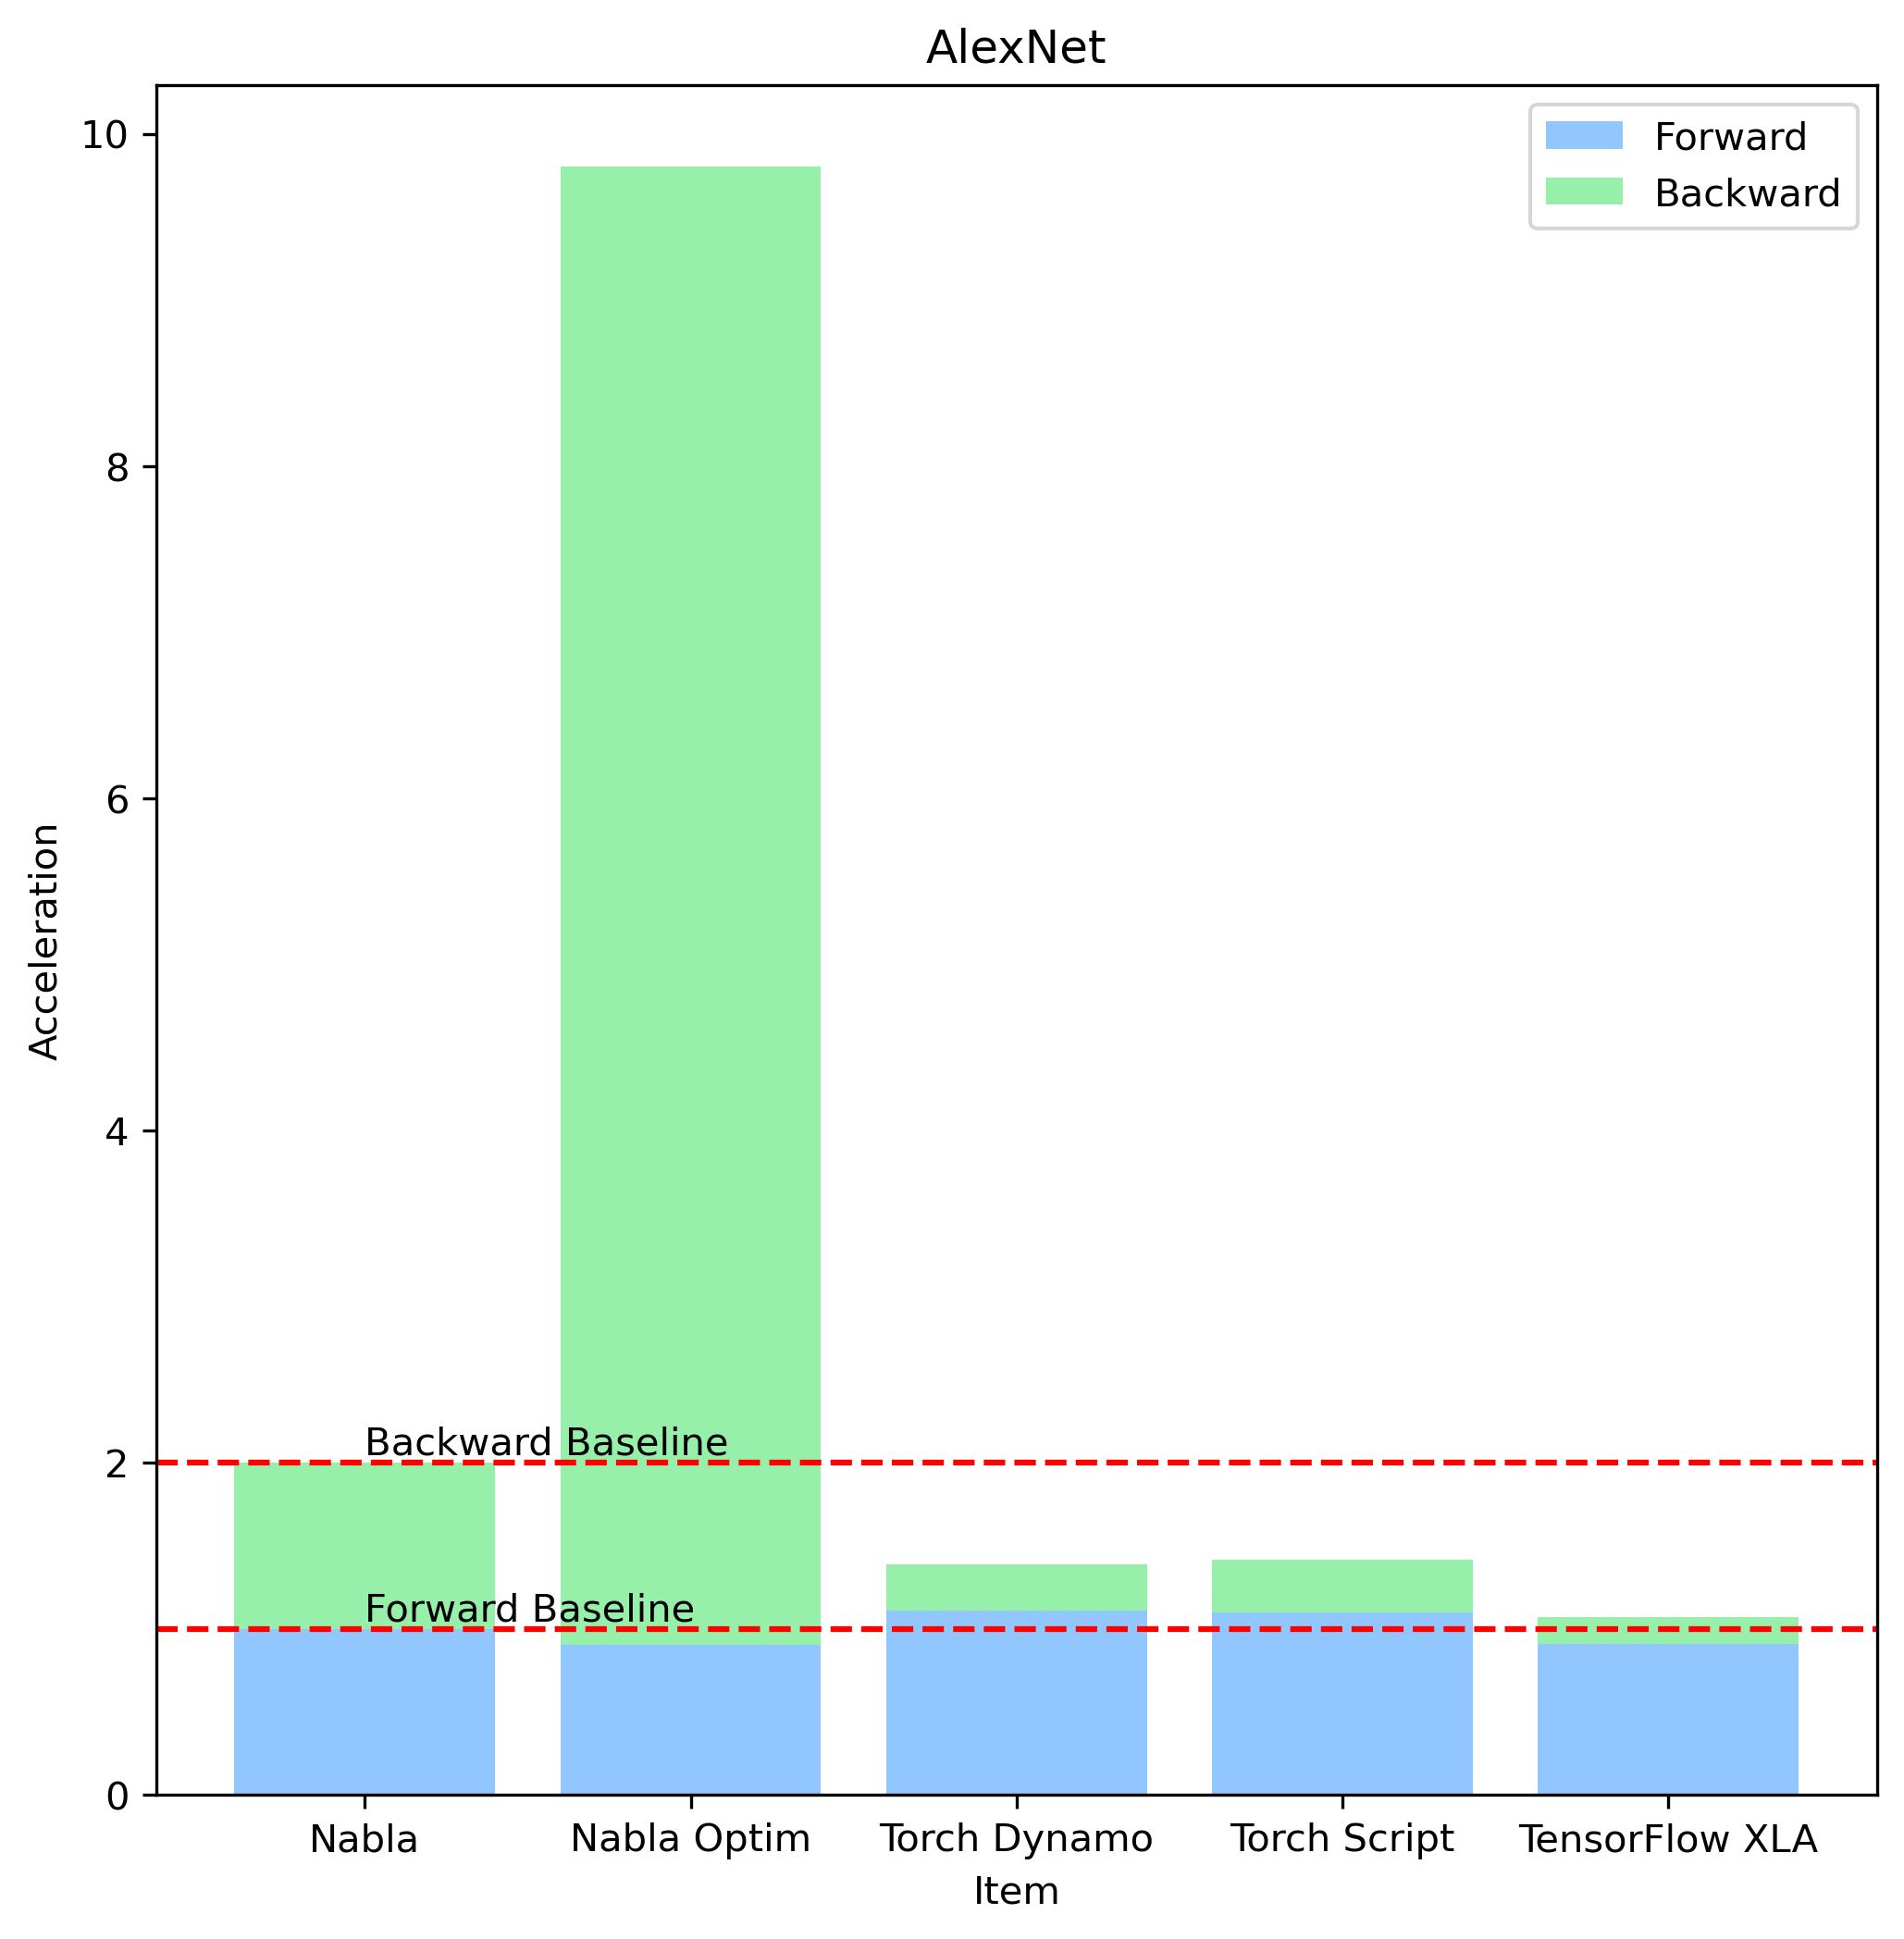

In [2]:
MODEL = "AlexNet"
PATH = f"{ROOT}/{MODEL.lower()}/"
torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

dfs = [torch2, torch1, tf]

for df in dfs:
    df.drop(
        columns="Unnamed: 0", inplace=True
    )
    df.drop(
        df[df["pass"] == "Full"].index, inplace=True
    )

torch2, torch1, tf = dfs

torch1.at[0, "item"] = "Torch Script"
torch1.at[3, "item"] = "Torch Script"

f_base, b_base, fo, bo = 0, 0, 0, 0
dfs = [torch2, torch1, tf]

for df in dfs:
    f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
    b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
    fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
    bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]

nabla_df = pd.DataFrame({
    "time": [f_base, b_base, fo, bo],
    "pass": ["Forward", "Backward"] * 2,
    "item": ["Nabla"] * 2 + ["Nabla Optim"] * 2
}, index=[0] * 4)
nabla_df

for df in dfs:
    nabla_df = pd.concat([
        nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
    ])
    
nabla_df.style.hide(axis="index")
f = nabla_df[nabla_df["pass"] == "Forward"]
b = nabla_df[nabla_df["pass"] == "Backward"]
f["acceleration"] = f_base / f["time"]
b["acceleration"] = b_base / b["time"]

items = ["Nabla", "Nabla Optim", "Torch Dynamo", "Torch Script", "TensorFlow XLA"]
plt.figure(dpi=300, figsize=(8, 8))

plt.bar(items, f["acceleration"], label="Forward")
plt.bar(items, b["acceleration"], label="Backward", bottom=f["acceleration"])

plt.xlabel("Item")
plt.ylabel("Acceleration")
plt.title(f"{MODEL}")
plt.legend()

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Forward Baseline", ha="left", va="bottom")
plt.axhline(2, color="red", linestyle="--", label="Baseline")
plt.text(0, 2, "Backward Baseline", ha="left", va="bottom")

print_time()

## ResNet18

Model: ResNet18
Forward:
  14.386881534010172
  18.722020592540503
  13.840251406654716
  21.97097702883184
  24.749190462753177
Backward:
  38.701093308627605
  21.054426065335672
  40.94039167277515
  30.48112692311406
  71.1460412107408


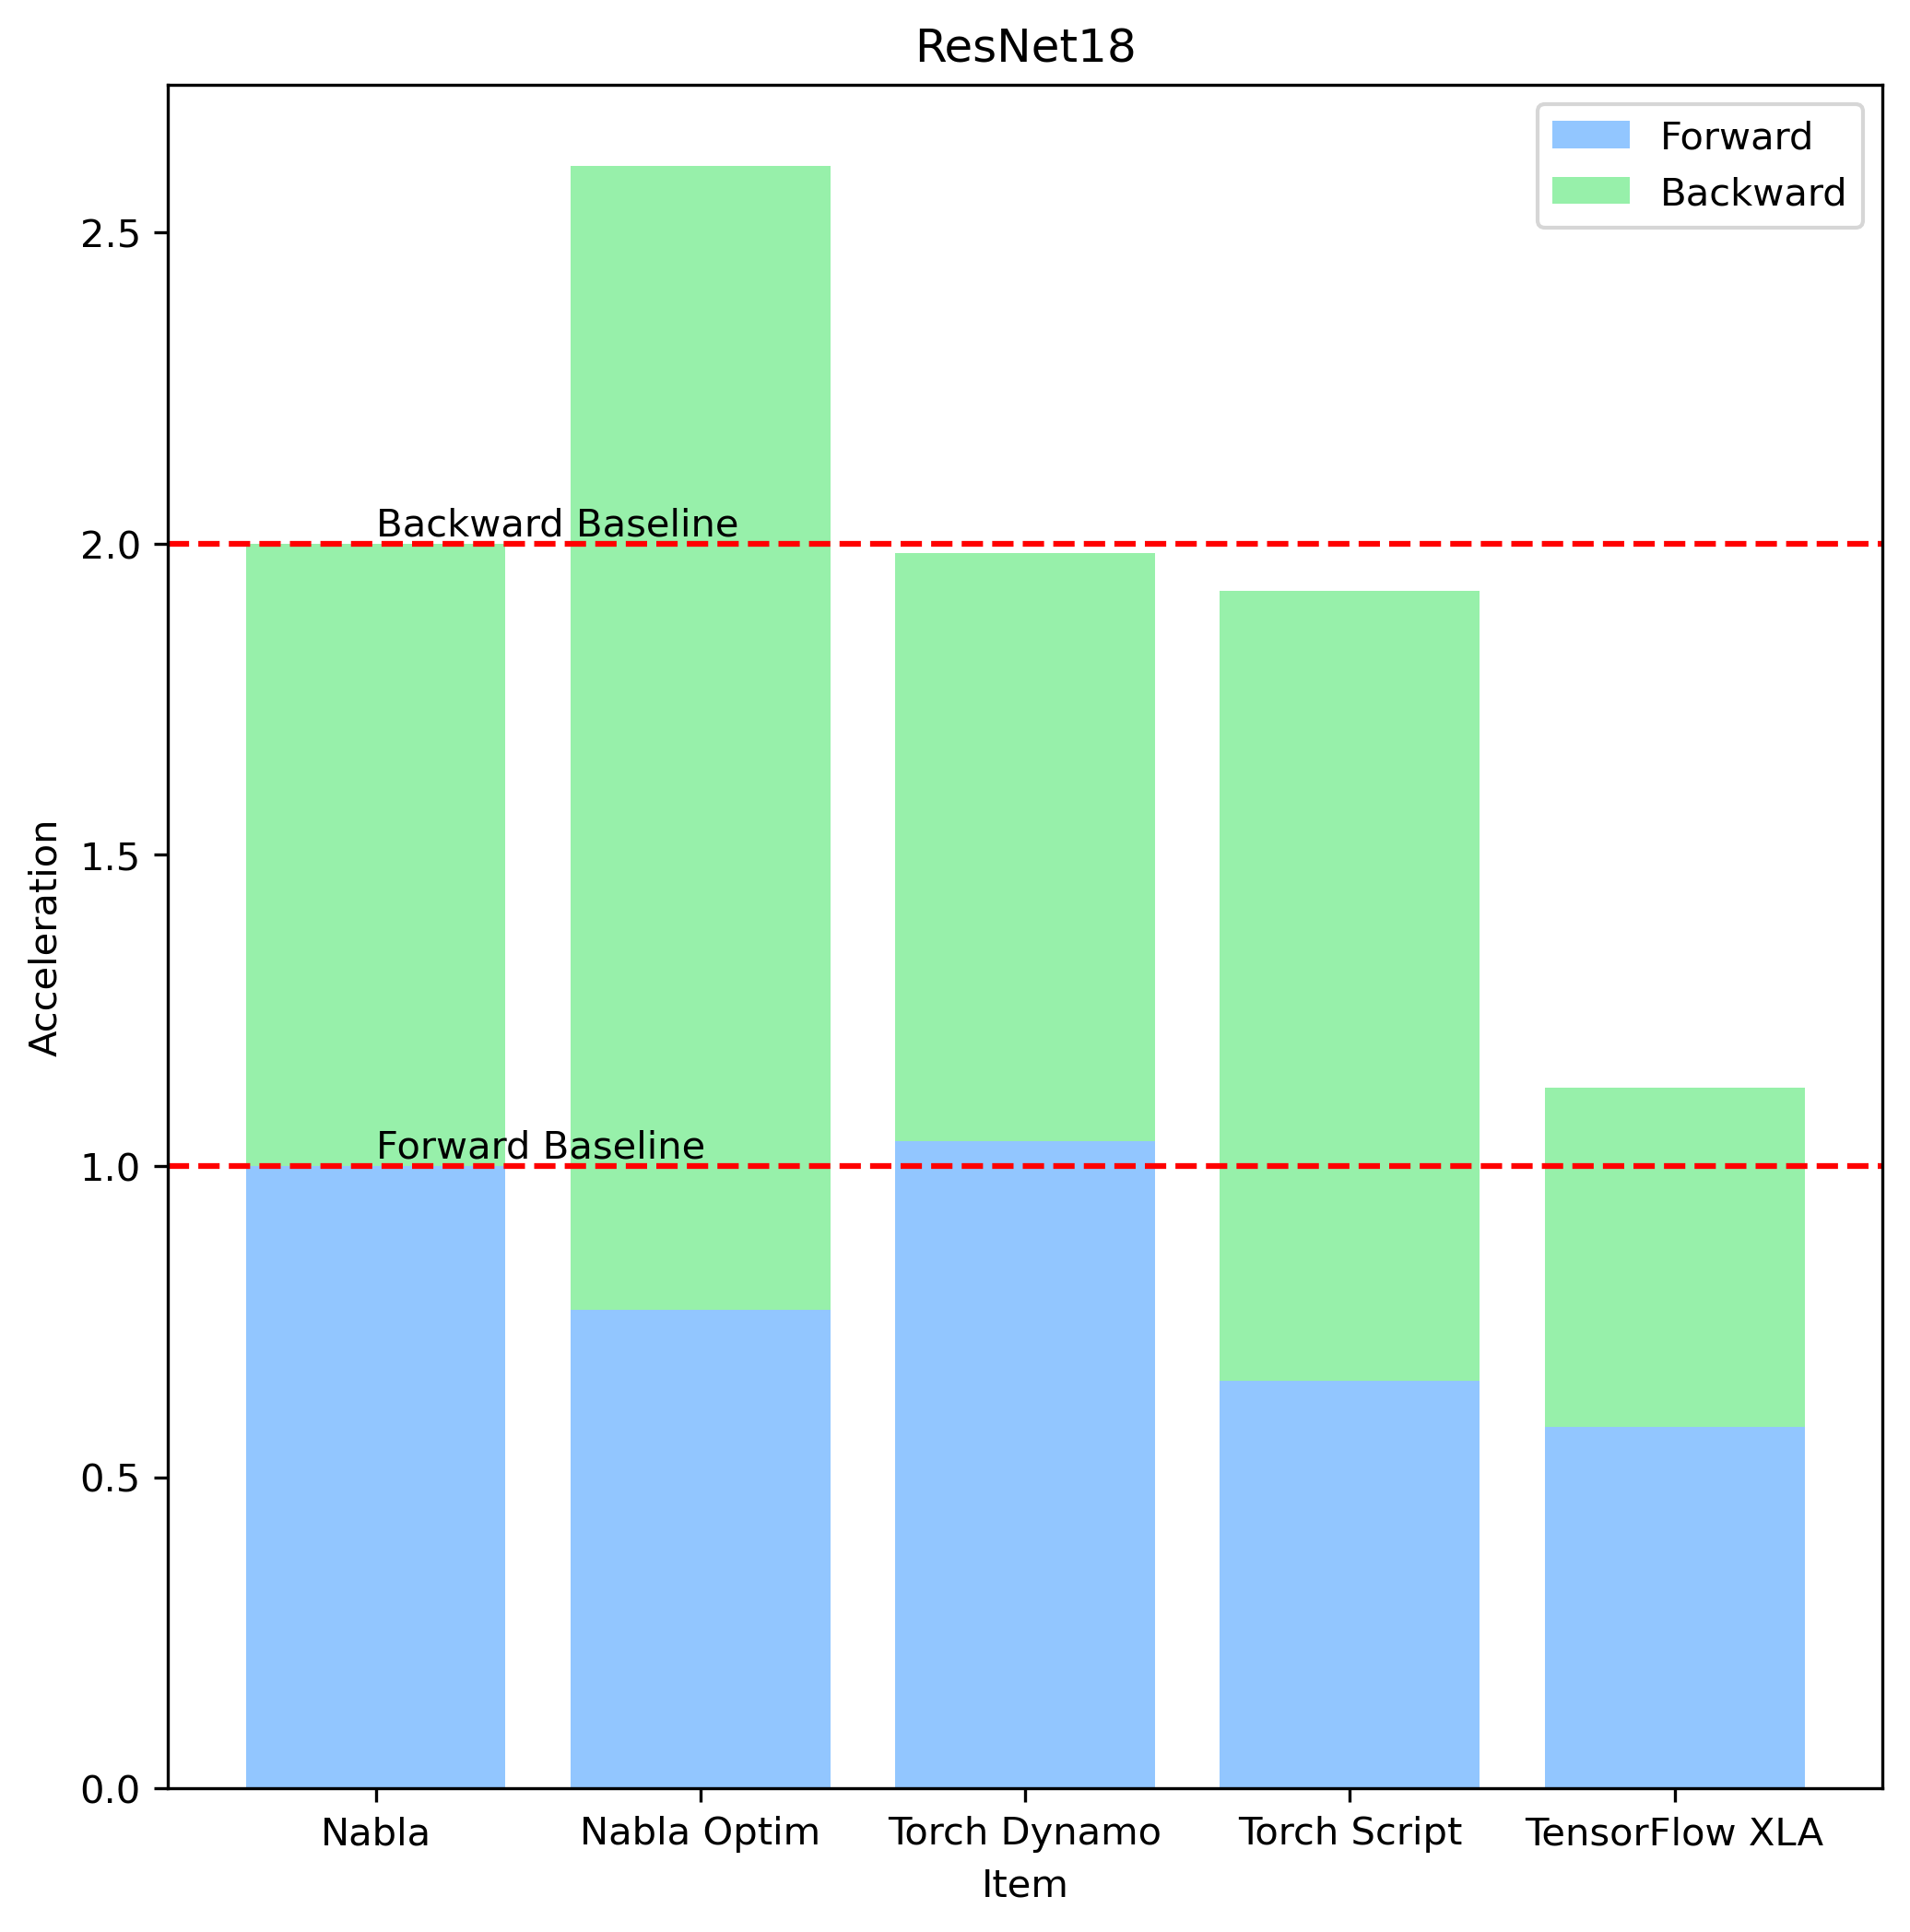

In [3]:
MODEL = "ResNet18"
PATH = f"{ROOT}/{MODEL.lower()}/"
torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

dfs = [torch2, torch1, tf]

for df in dfs:
    df.drop(
        columns="Unnamed: 0", inplace=True
    )
    df.drop(
        df[df["pass"] == "Full"].index, inplace=True
    )

torch2, torch1, tf = dfs

torch1.at[0, "item"] = "Torch Script"
torch1.at[3, "item"] = "Torch Script"

f_base, b_base, fo, bo = 0, 0, 0, 0
dfs = [torch2, torch1, tf]

for df in dfs:
    f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
    b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
    fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
    bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]

nabla_df = pd.DataFrame({
    "time": [f_base, b_base, fo, bo],
    "pass": ["Forward", "Backward"] * 2,
    "item": ["Nabla"] * 2 + ["Nabla Optim"] * 2
}, index=[0] * 4)
nabla_df

for df in dfs:
    nabla_df = pd.concat([
        nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
    ])
    
nabla_df.style.hide(axis="index")
f = nabla_df[nabla_df["pass"] == "Forward"]
b = nabla_df[nabla_df["pass"] == "Backward"]
f["acceleration"] = f_base / f["time"]
b["acceleration"] = b_base / b["time"]

items = ["Nabla", "Nabla Optim", "Torch Dynamo", "Torch Script", "TensorFlow XLA"]
plt.figure(dpi=300, figsize=(8, 8))

plt.bar(items, f["acceleration"], label="Forward")
plt.bar(items, b["acceleration"], label="Backward", bottom=f["acceleration"])

plt.xlabel("Item")
plt.ylabel("Acceleration")
plt.title(f"{MODEL}")
plt.legend()

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Forward Baseline", ha="left", va="bottom")
plt.axhline(2, color="red", linestyle="--", label="Baseline")
plt.text(0, 2, "Backward Baseline", ha="left", va="bottom")

print_time()

## ResNet34

Model: ResNet34
Forward:
  27.64680653810501
  31.684953679020207
  27.05070761963725
  28.317052386701107
  46.19381431490183
Backward:
  60.050722820063434
  22.39208746701479
  71.50693386793137
  41.49367718026042
  119.7645899374038


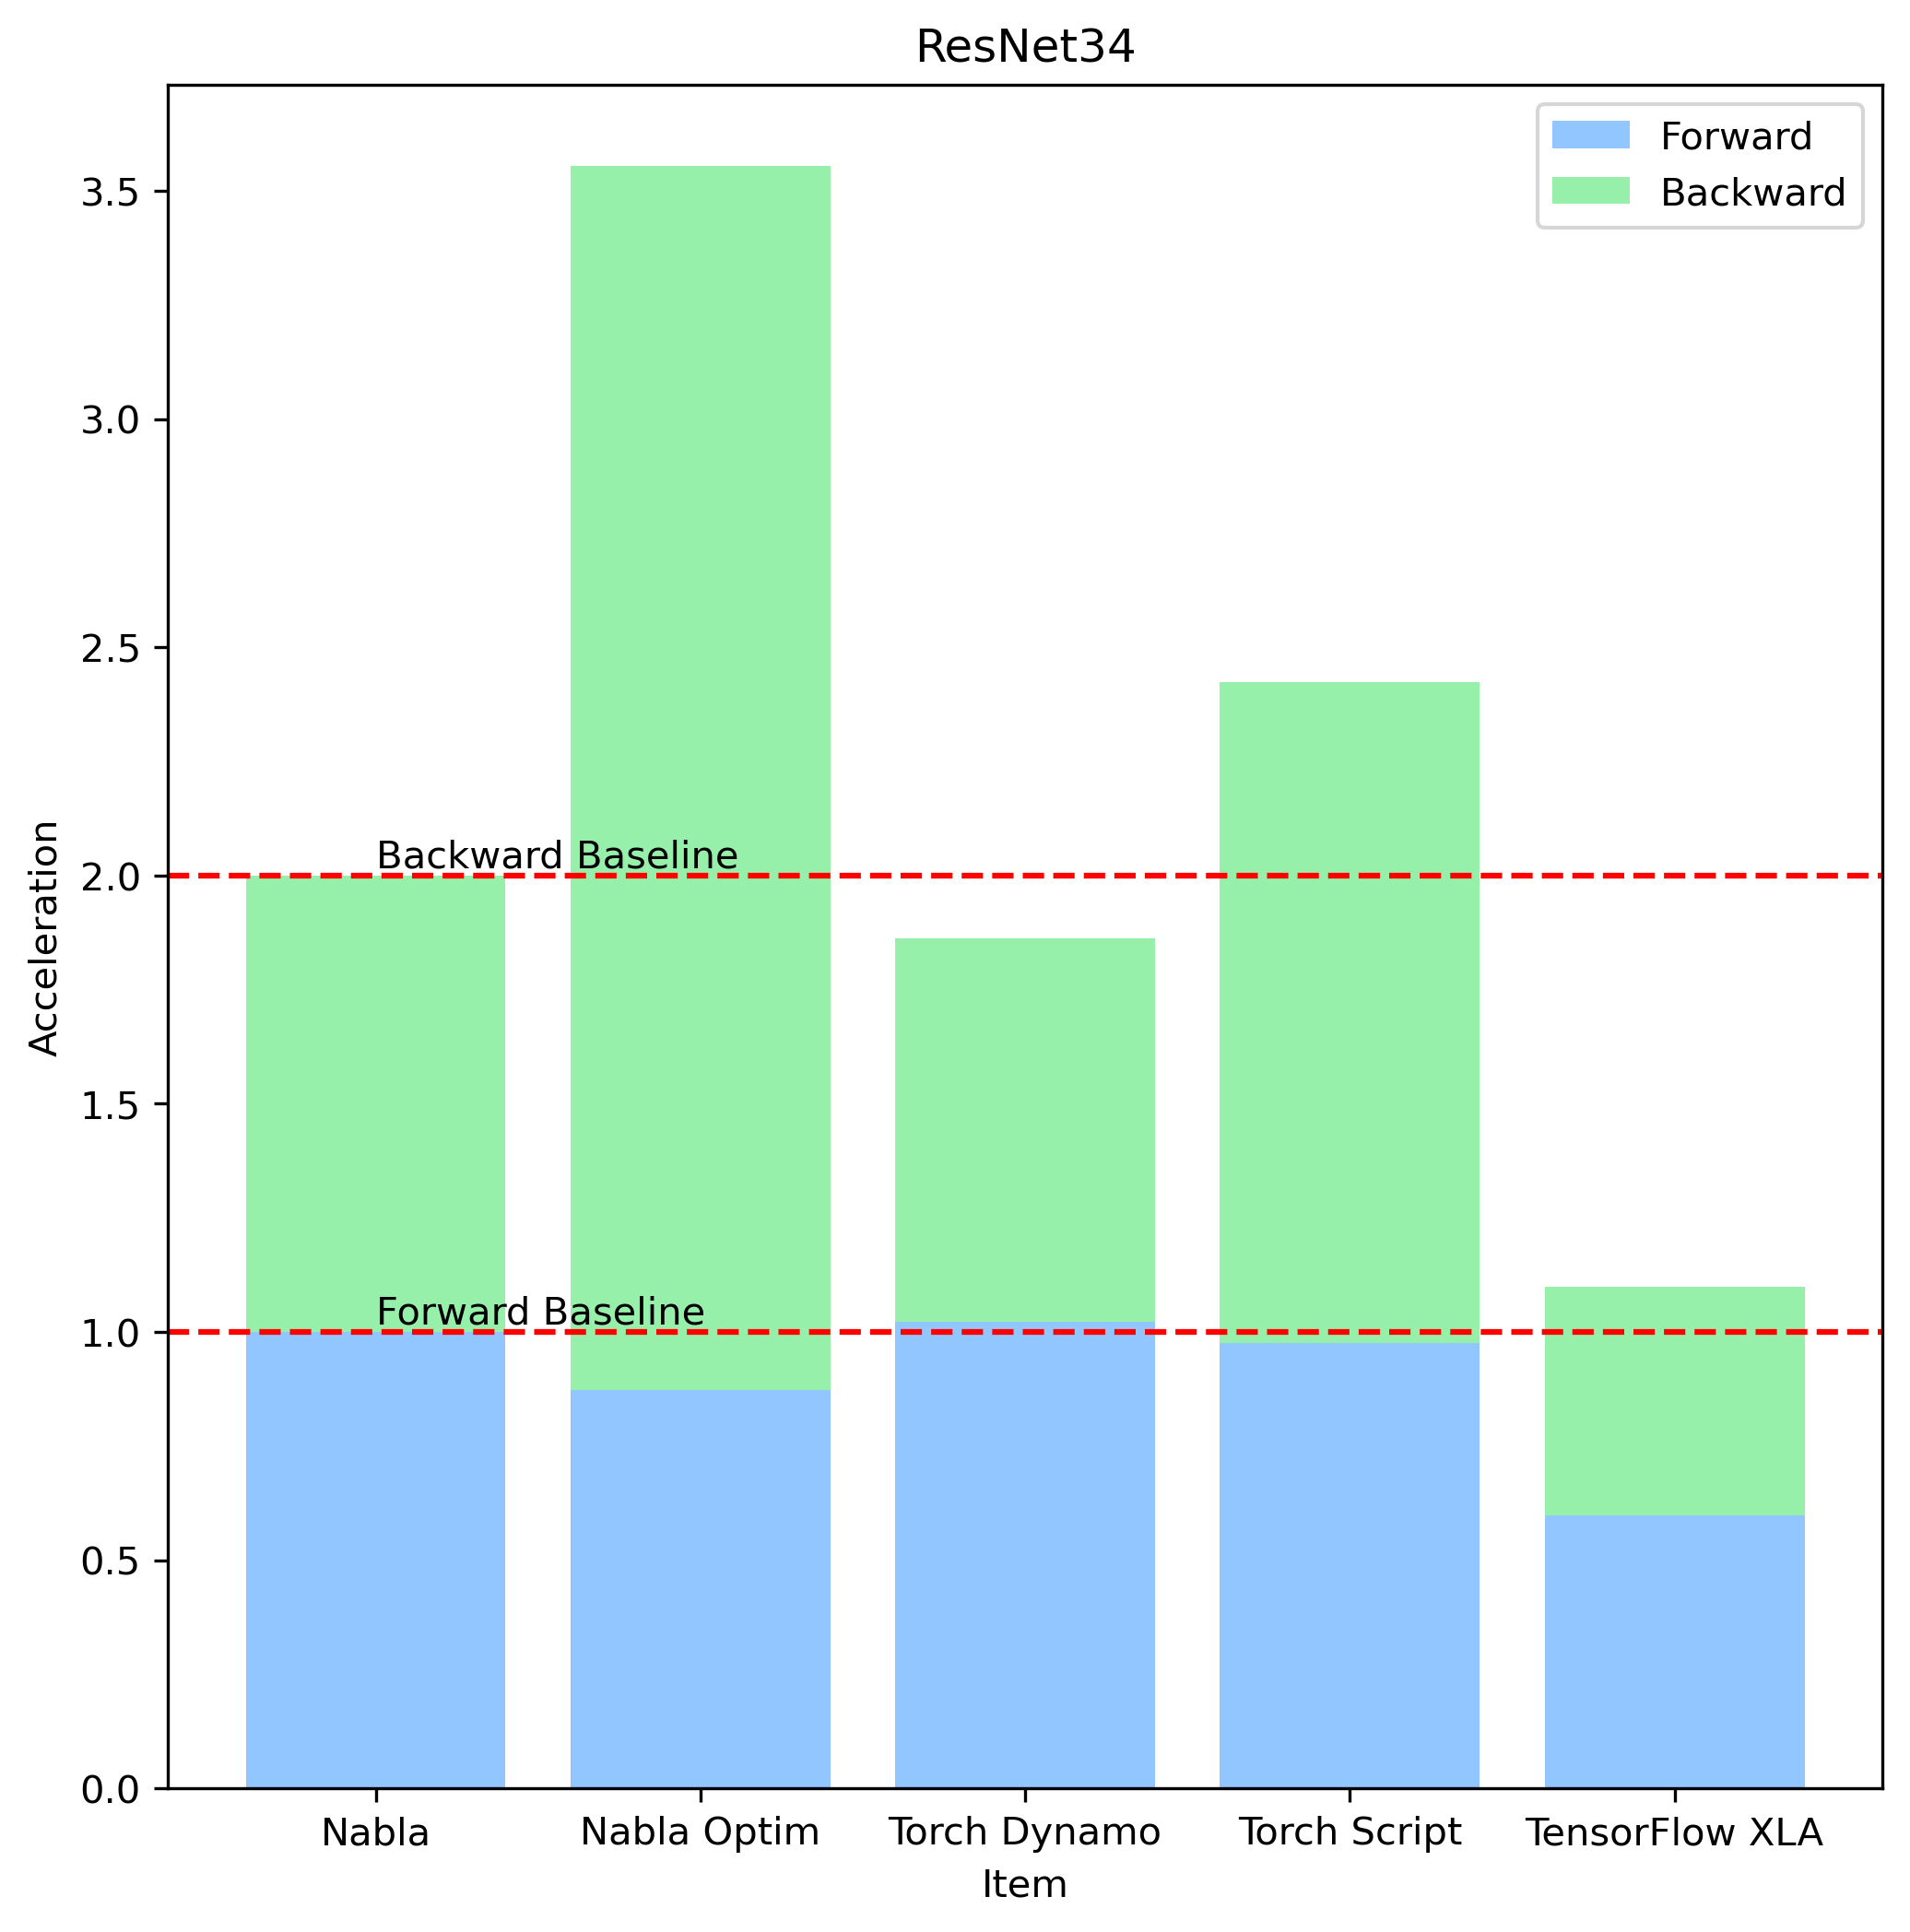

In [4]:
MODEL = "ResNet34"
PATH = f"{ROOT}/{MODEL.lower()}/"
torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

dfs = [torch2, torch1, tf]

for df in dfs:
    df.drop(
        columns="Unnamed: 0", inplace=True
    )
    df.drop(
        df[df["pass"] == "Full"].index, inplace=True
    )

torch2, torch1, tf = dfs

torch1.at[0, "item"] = "Torch Script"
torch1.at[3, "item"] = "Torch Script"

f_base, b_base, fo, bo = 0, 0, 0, 0
dfs = [torch2, torch1, tf]

for df in dfs:
    f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
    b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
    fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
    bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]

nabla_df = pd.DataFrame({
    "time": [f_base, b_base, fo, bo],
    "pass": ["Forward", "Backward"] * 2,
    "item": ["Nabla"] * 2 + ["Nabla Optim"] * 2
}, index=[0] * 4)
nabla_df

for df in dfs:
    nabla_df = pd.concat([
        nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
    ])
    
nabla_df.style.hide(axis="index")
f = nabla_df[nabla_df["pass"] == "Forward"]
b = nabla_df[nabla_df["pass"] == "Backward"]
f["acceleration"] = f_base / f["time"]
b["acceleration"] = b_base / b["time"]

items = ["Nabla", "Nabla Optim", "Torch Dynamo", "Torch Script", "TensorFlow XLA"]
plt.figure(dpi=300, figsize=(8, 8))

plt.bar(items, f["acceleration"], label="Forward")
plt.bar(items, b["acceleration"], label="Backward", bottom=f["acceleration"])

plt.xlabel("Item")
plt.ylabel("Acceleration")
plt.title(f"{MODEL}")
plt.legend()

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Forward Baseline", ha="left", va="bottom")
plt.axhline(2, color="red", linestyle="--", label="Baseline")
plt.text(0, 2, "Backward Baseline", ha="left", va="bottom")

print_time()

## ResNet50

Model: ResNet50
Forward:
  45.42426748201251
  55.64653222138683
  38.05712375789881
  81.22243122197688
  58.9706817548722
Backward:
  165.3812097106129
  110.37374199988942
  119.1507689934224
  114.75095367059112
  154.16332836262882


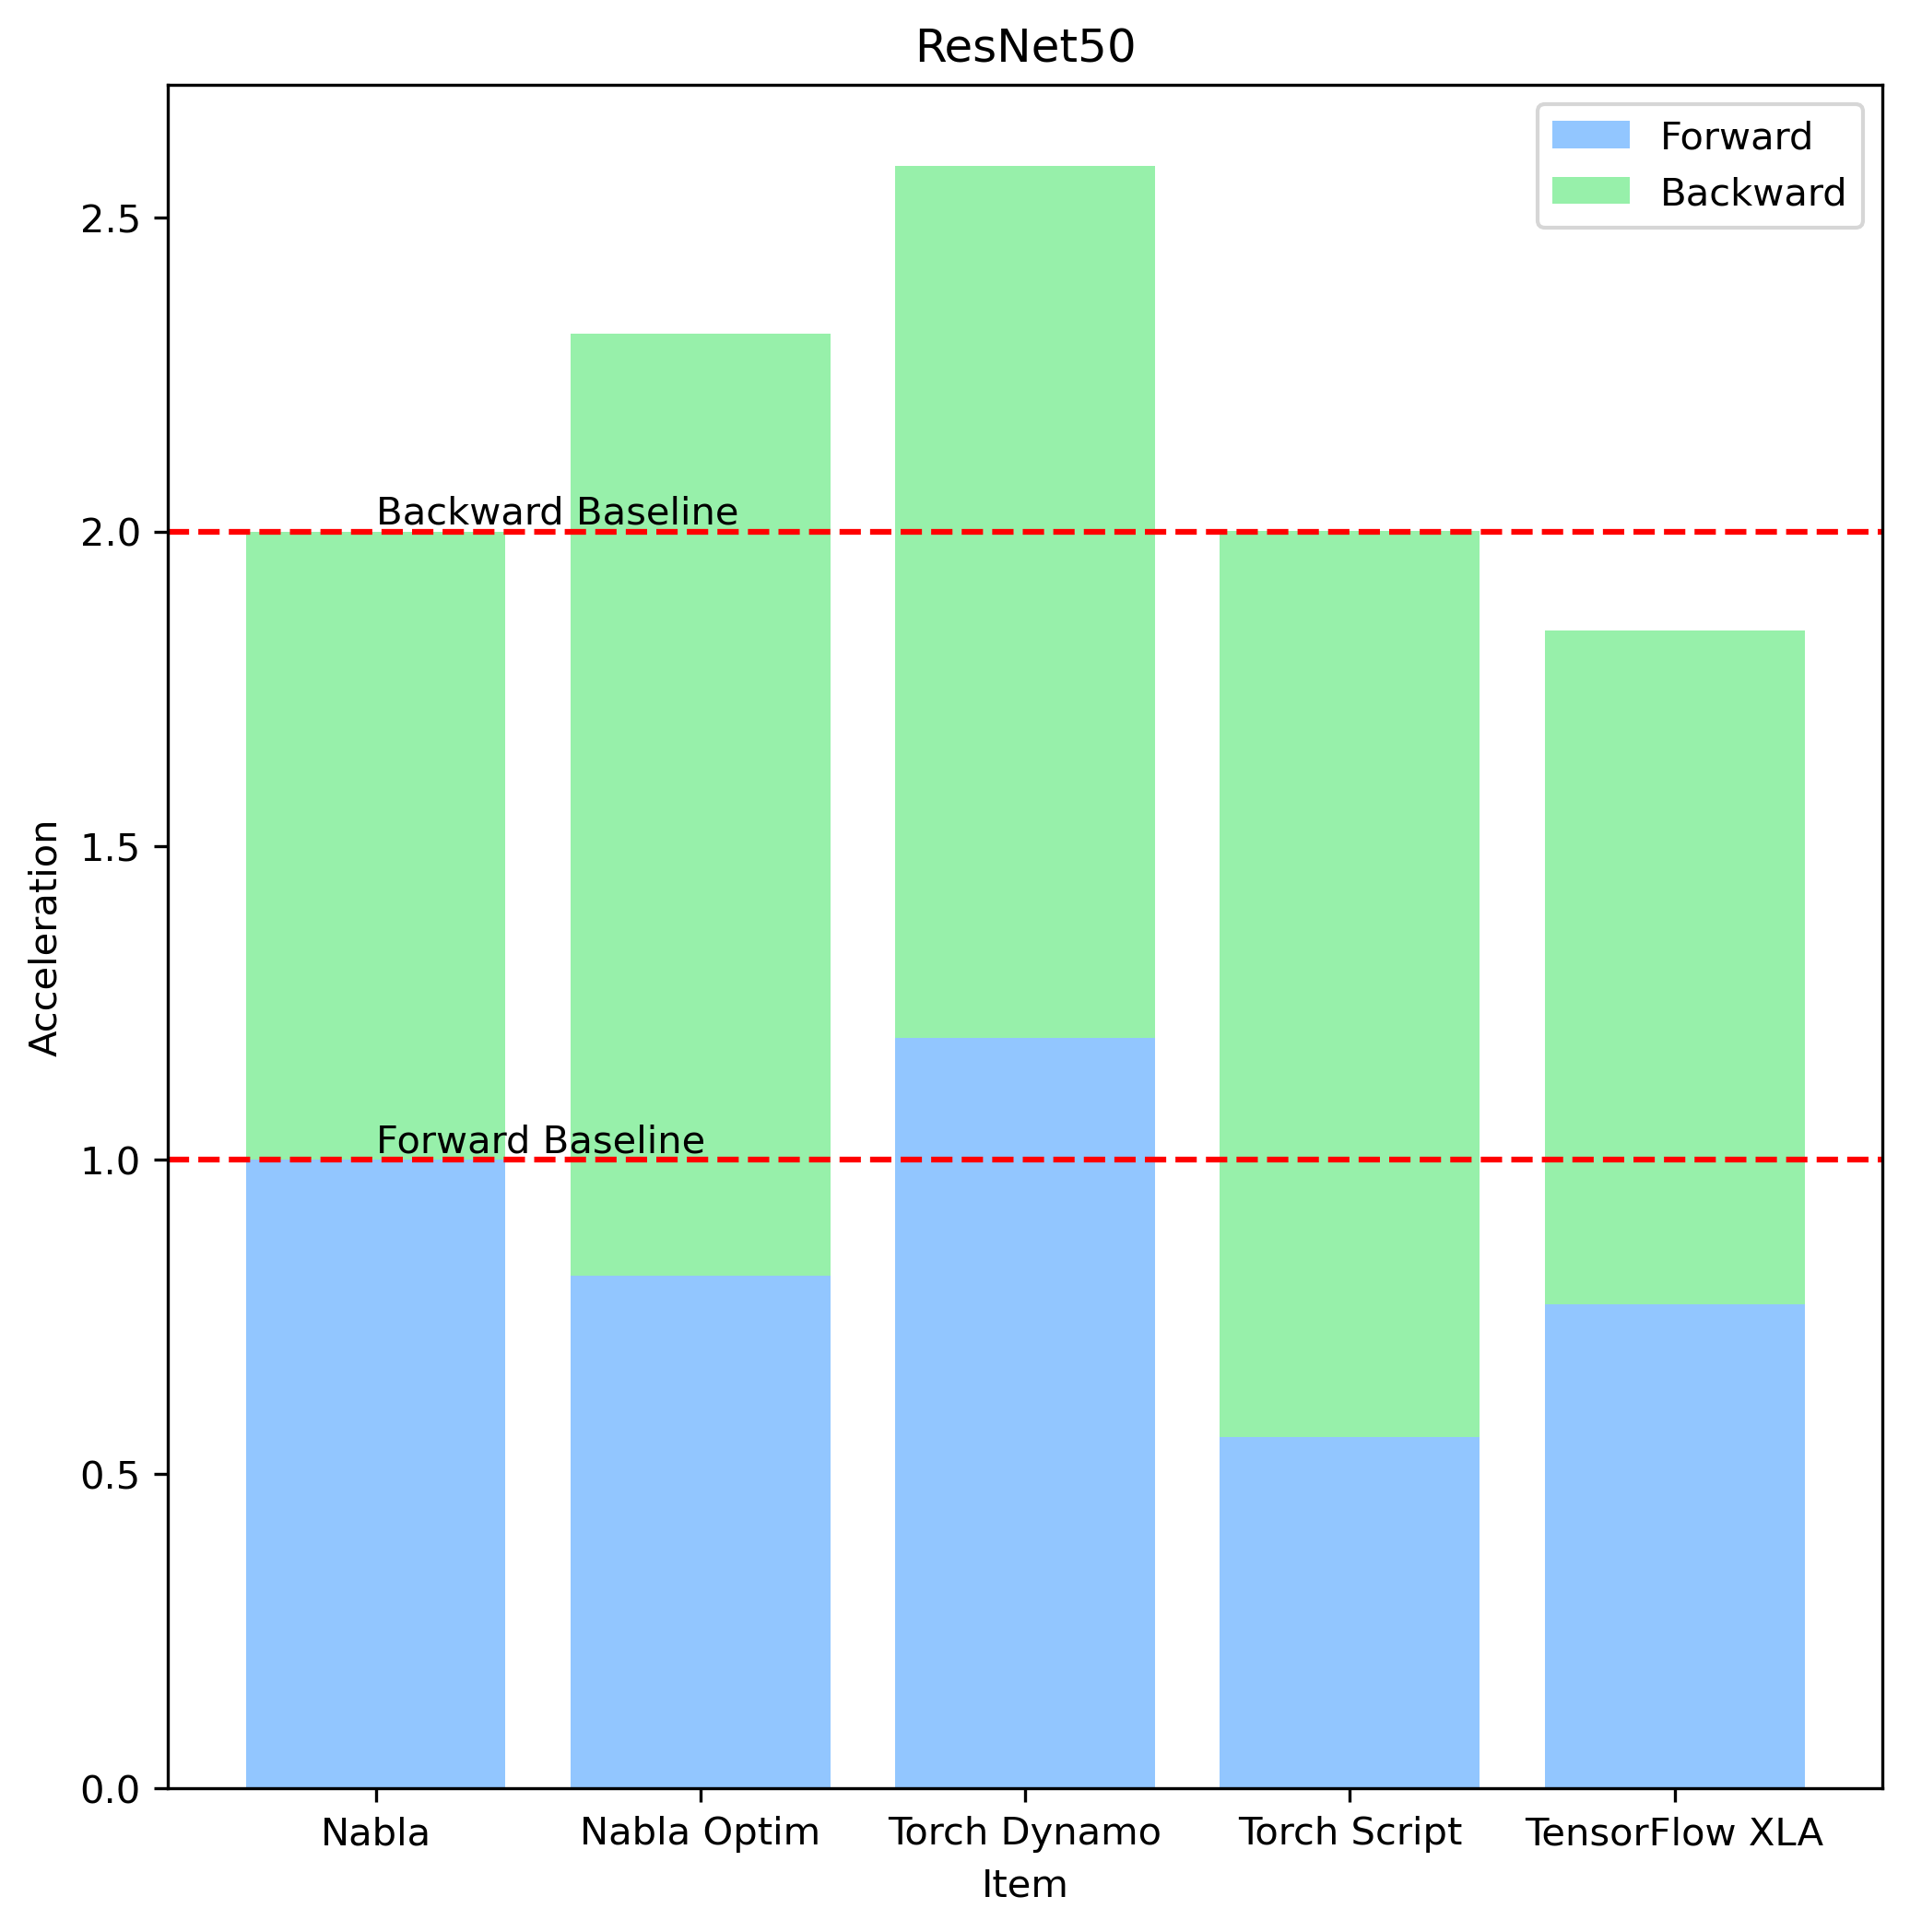

In [5]:
MODEL = "ResNet50"
PATH = f"{ROOT}/{MODEL.lower()}/"
torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

dfs = [torch2, torch1, tf]

for df in dfs:
    df.drop(
        columns="Unnamed: 0", inplace=True
    )
    df.drop(
        df[df["pass"] == "Full"].index, inplace=True
    )

torch2, torch1, tf = dfs

torch1.at[0, "item"] = "Torch Script"
torch1.at[3, "item"] = "Torch Script"

f_base, b_base, fo, bo = 0, 0, 0, 0
dfs = [torch2, torch1, tf]

for df in dfs:
    f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
    b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
    fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
    bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]

nabla_df = pd.DataFrame({
    "time": [f_base, b_base, fo, bo],
    "pass": ["Forward", "Backward"] * 2,
    "item": ["Nabla"] * 2 + ["Nabla Optim"] * 2
}, index=[0] * 4)
nabla_df

for df in dfs:
    nabla_df = pd.concat([
        nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
    ])
    
nabla_df.style.hide(axis="index")
f = nabla_df[nabla_df["pass"] == "Forward"]
b = nabla_df[nabla_df["pass"] == "Backward"]
f["acceleration"] = f_base / f["time"]
b["acceleration"] = b_base / b["time"]

items = ["Nabla", "Nabla Optim", "Torch Dynamo", "Torch Script", "TensorFlow XLA"]
plt.figure(dpi=300, figsize=(8, 8))

plt.bar(items, f["acceleration"], label="Forward")
plt.bar(items, b["acceleration"], label="Backward", bottom=f["acceleration"])

plt.xlabel("Item")
plt.ylabel("Acceleration")
plt.title(f"{MODEL}")
plt.legend()

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Forward Baseline", ha="left", va="bottom")
plt.axhline(2, color="red", linestyle="--", label="Baseline")
plt.text(0, 2, "Backward Baseline", ha="left", va="bottom")

print_time()

## ResNet101

Model: ResNet101
Forward:
  72.58621490870912
  87.0749354797105
  59.91211345419288
  143.77490936778486
  113.72827239334585
Backward:
  209.17075996908048
  110.9173097430418
  284.1541106067598
  204.6865324769169
  269.3034045491368


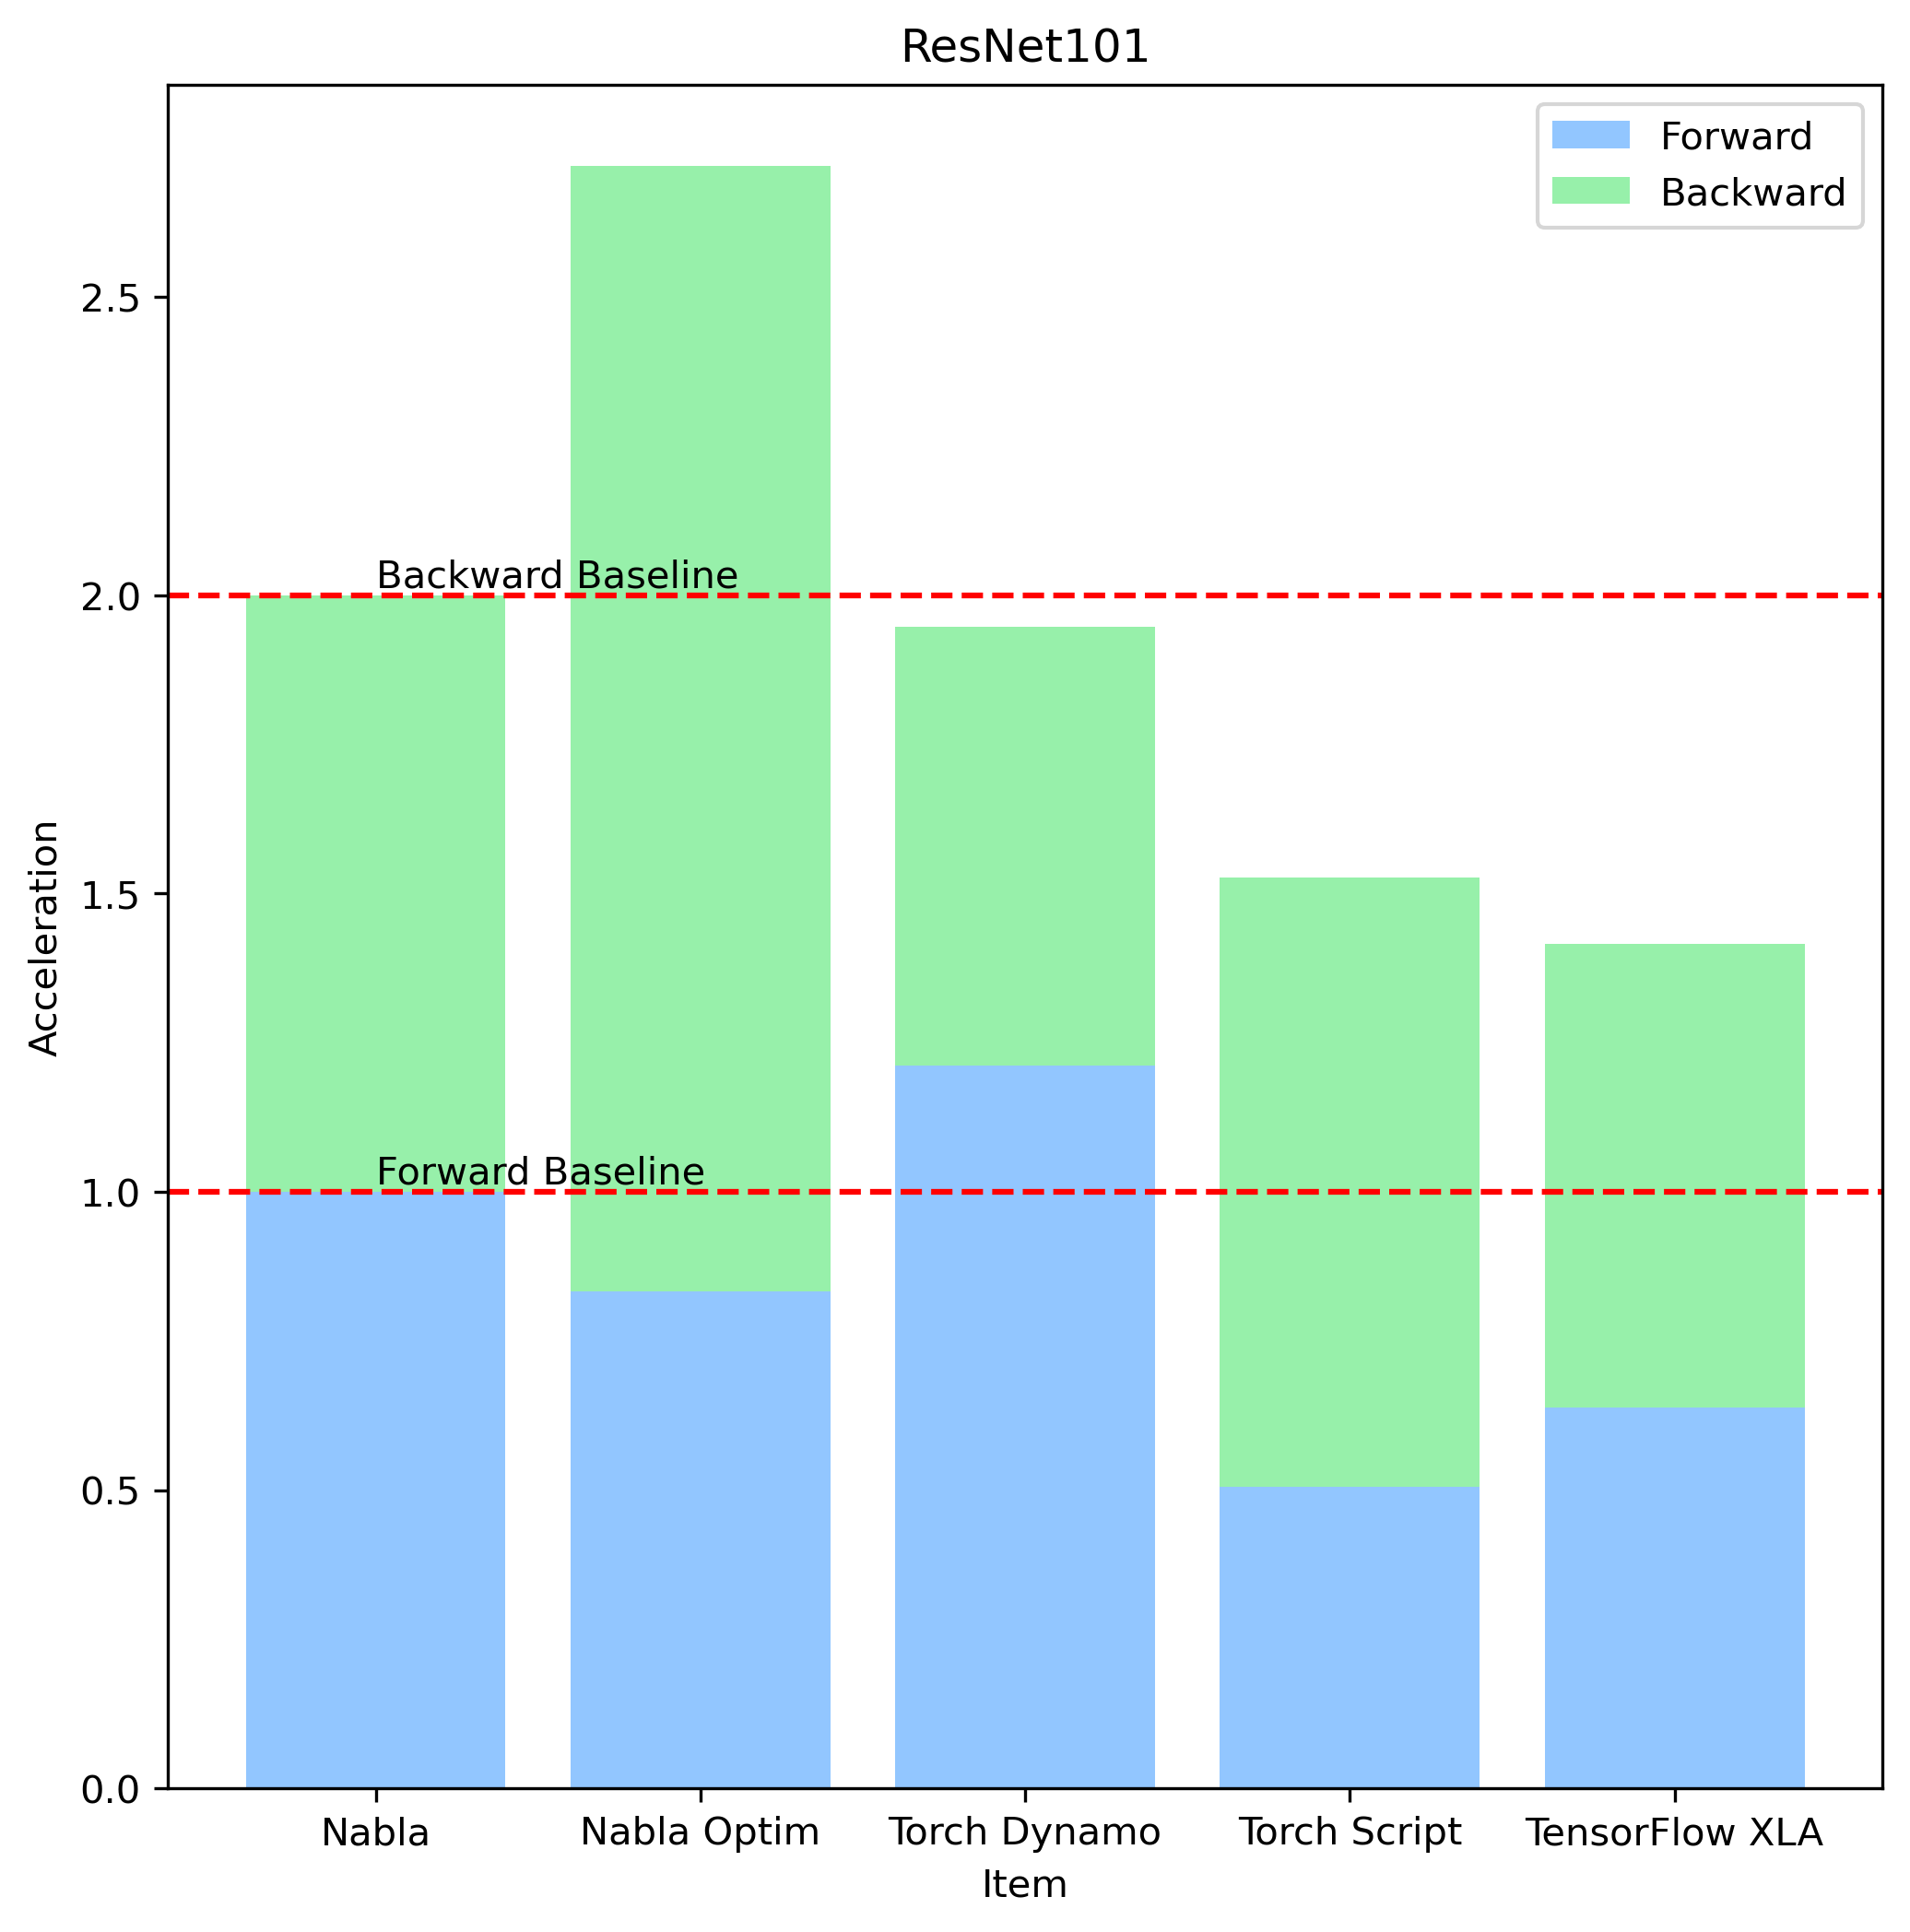

In [6]:
MODEL = "ResNet101"
PATH = f"{ROOT}/{MODEL.lower()}/"
torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

dfs = [torch2, torch1, tf]

for df in dfs:
    df.drop(
        columns="Unnamed: 0", inplace=True
    )
    df.drop(
        df[df["pass"] == "Full"].index, inplace=True
    )

torch2, torch1, tf = dfs

torch1.at[0, "item"] = "Torch Script"
torch1.at[3, "item"] = "Torch Script"

f_base, b_base, fo, bo = 0, 0, 0, 0
dfs = [torch2, torch1, tf]

for df in dfs:
    f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
    b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
    fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
    bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]

nabla_df = pd.DataFrame({
    "time": [f_base, b_base, fo, bo],
    "pass": ["Forward", "Backward"] * 2,
    "item": ["Nabla"] * 2 + ["Nabla Optim"] * 2
}, index=[0] * 4)
nabla_df

for df in dfs:
    nabla_df = pd.concat([
        nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
    ])
    
nabla_df.style.hide(axis="index")
f = nabla_df[nabla_df["pass"] == "Forward"]
b = nabla_df[nabla_df["pass"] == "Backward"]
f["acceleration"] = f_base / f["time"]
b["acceleration"] = b_base / b["time"]

items = ["Nabla", "Nabla Optim", "Torch Dynamo", "Torch Script", "TensorFlow XLA"]
plt.figure(dpi=300, figsize=(8, 8))

plt.bar(items, f["acceleration"], label="Forward")
plt.bar(items, b["acceleration"], label="Backward", bottom=f["acceleration"])

plt.xlabel("Item")
plt.ylabel("Acceleration")
plt.title(f"{MODEL}")
plt.legend()

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Forward Baseline", ha="left", va="bottom")
plt.axhline(2, color="red", linestyle="--", label="Baseline")
plt.text(0, 2, "Backward Baseline", ha="left", va="bottom")

print_time()

## ResNet152

Model: ResNet152
Forward:
  124.03605423557262
  147.81604247478148
  87.79281612485647
  208.65898022428155
  168.20360137149692
Backward:
  300.0133876937131
  122.37620927393436
  487.0416734181345
  295.196475116536
  387.50336300581694


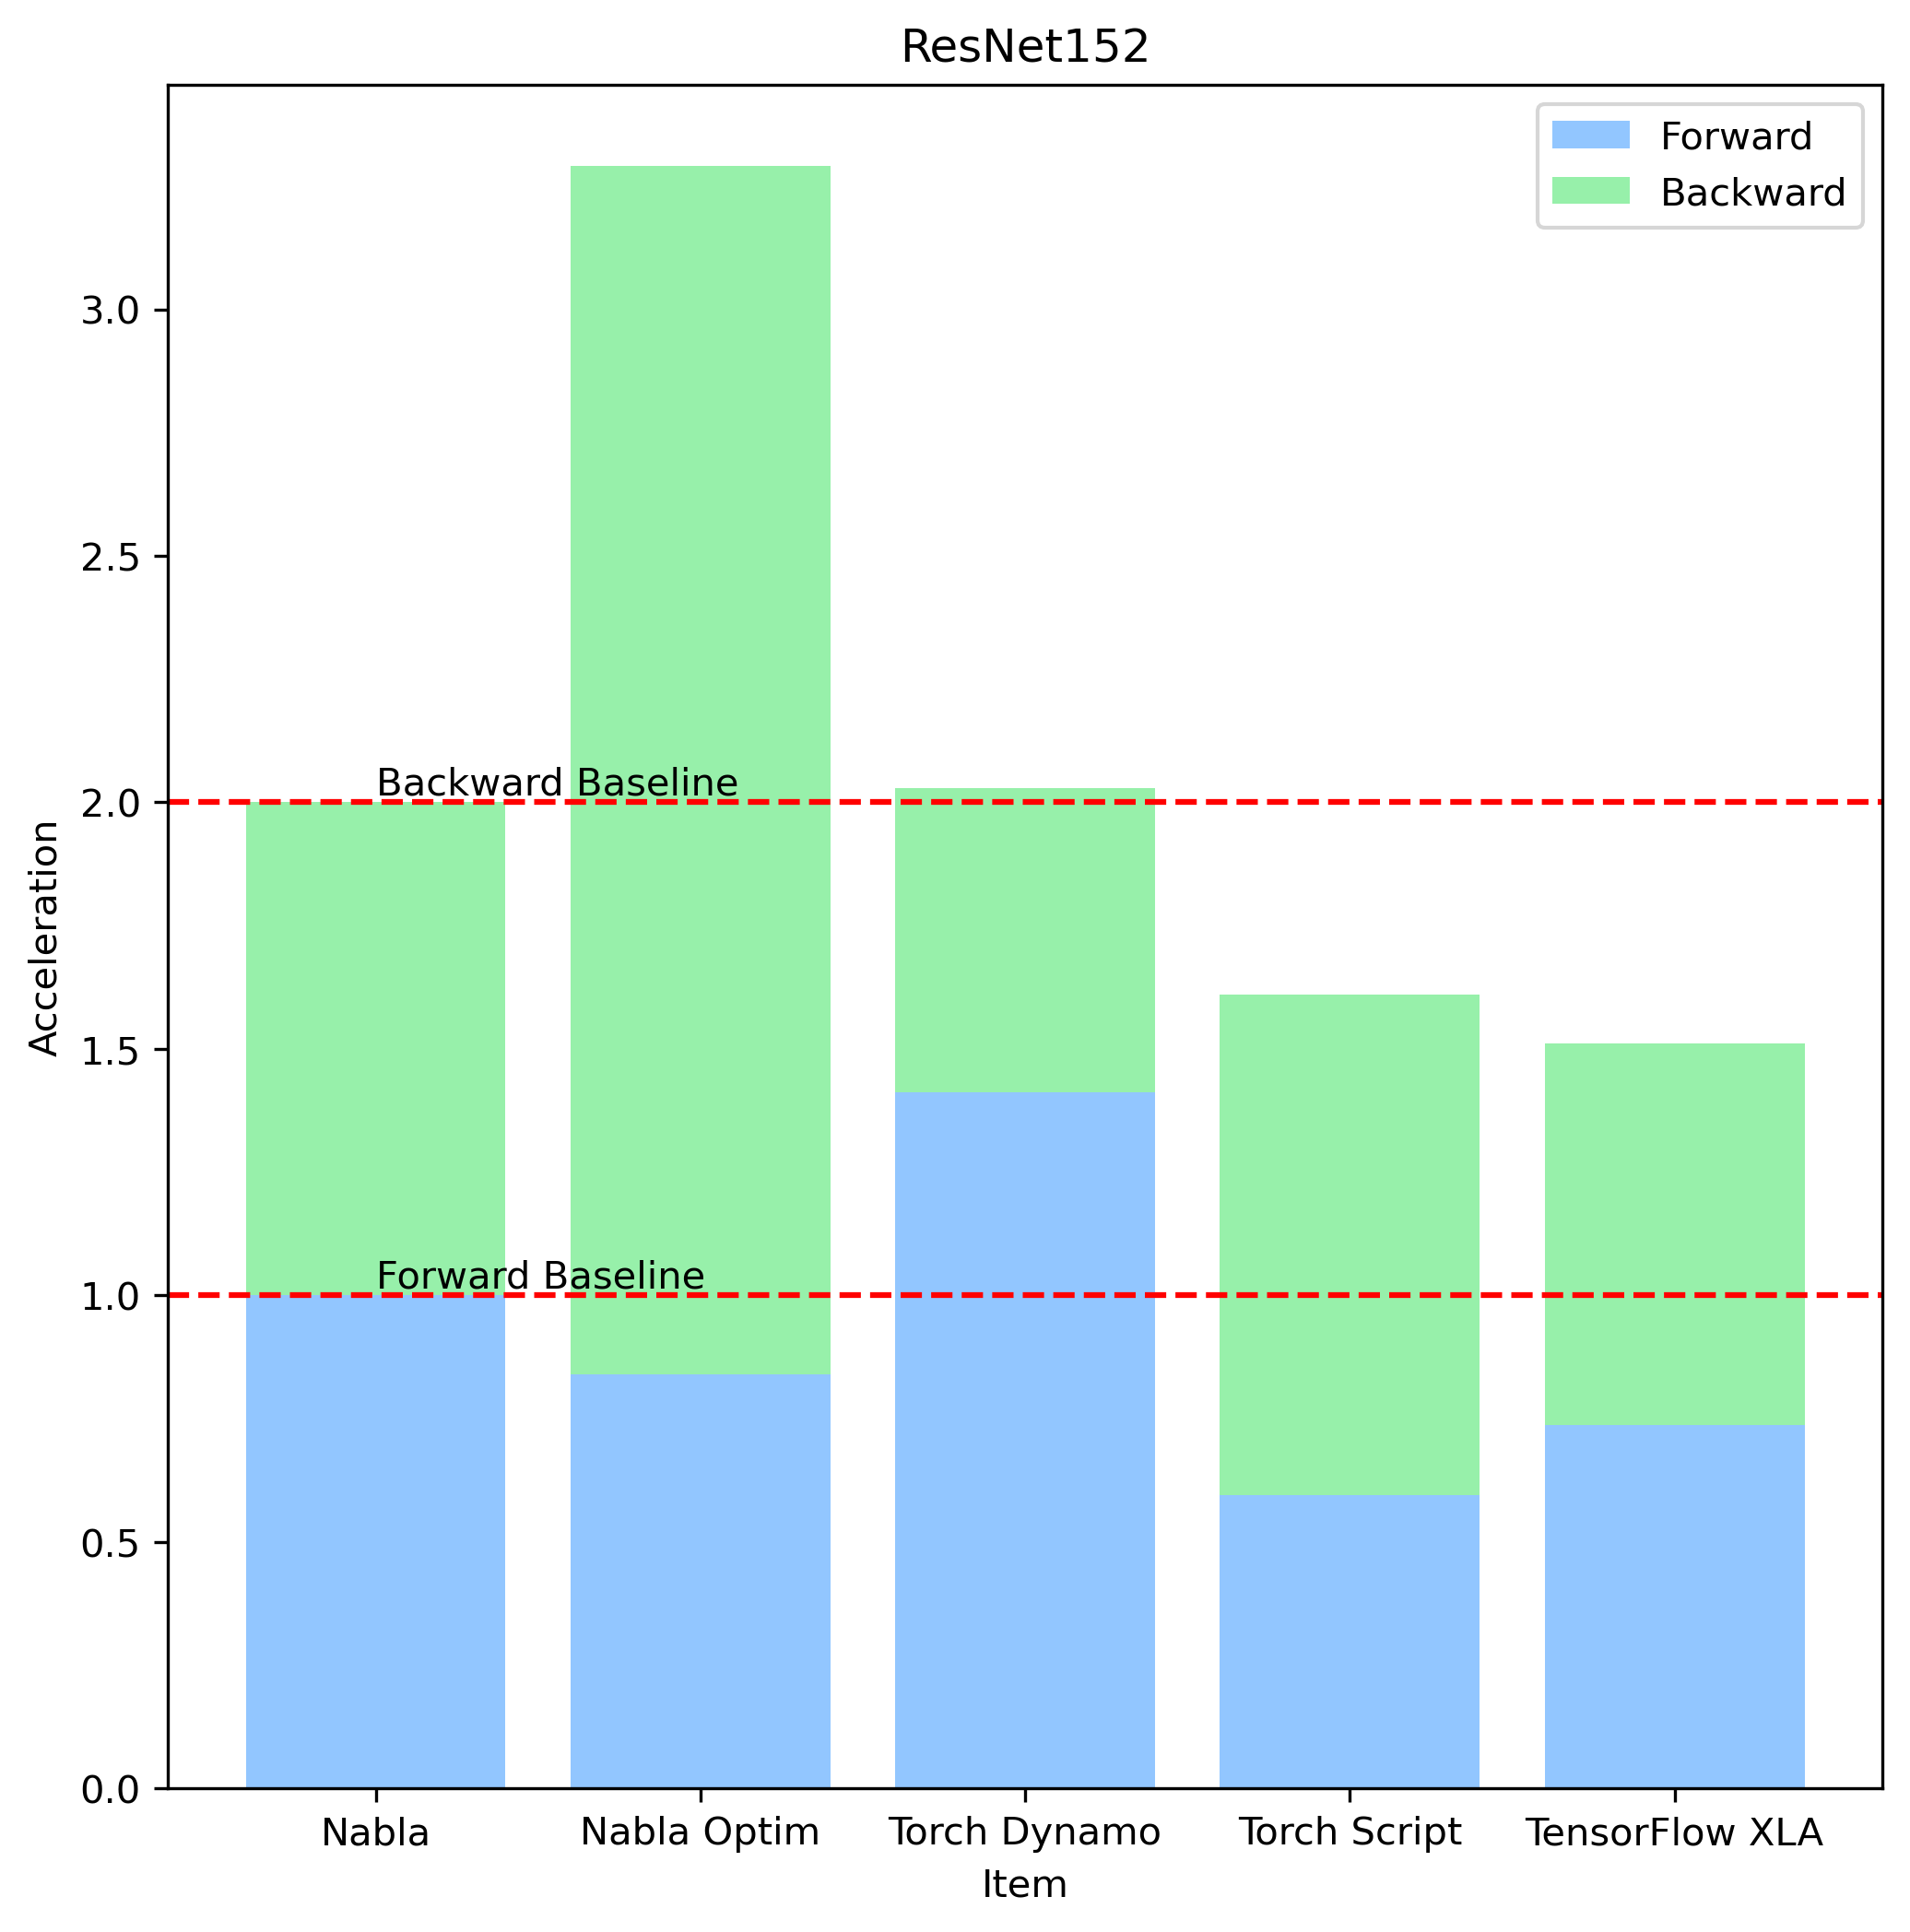

In [7]:
MODEL = "ResNet152"
PATH = f"{ROOT}/{MODEL.lower()}/"
torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

dfs = [torch2, torch1, tf]

for df in dfs:
    df.drop(
        columns="Unnamed: 0", inplace=True
    )
    df.drop(
        df[df["pass"] == "Full"].index, inplace=True
    )

torch2, torch1, tf = dfs

torch1.at[0, "item"] = "Torch Script"
torch1.at[3, "item"] = "Torch Script"

f_base, b_base, fo, bo = 0, 0, 0, 0
dfs = [torch2, torch1, tf]

for df in dfs:
    f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
    b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
    fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
    bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]

nabla_df = pd.DataFrame({
    "time": [f_base, b_base, fo, bo],
    "pass": ["Forward", "Backward"] * 2,
    "item": ["Nabla"] * 2 + ["Nabla Optim"] * 2
}, index=[0] * 4)
nabla_df

for df in dfs:
    nabla_df = pd.concat([
        nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
    ])
    
nabla_df.style.hide(axis="index")
f = nabla_df[nabla_df["pass"] == "Forward"]
b = nabla_df[nabla_df["pass"] == "Backward"]
f["acceleration"] = f_base / f["time"]
b["acceleration"] = b_base / b["time"]

items = ["Nabla", "Nabla Optim", "Torch Dynamo", "Torch Script", "TensorFlow XLA"]
plt.figure(dpi=300, figsize=(8, 8))

plt.bar(items, f["acceleration"], label="Forward")
plt.bar(items, b["acceleration"], label="Backward", bottom=f["acceleration"])

plt.xlabel("Item")
plt.ylabel("Acceleration")
plt.title(f"{MODEL}")
plt.legend()

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Forward Baseline", ha="left", va="bottom")
plt.axhline(2, color="red", linestyle="--", label="Baseline")
plt.text(0, 2, "Backward Baseline", ha="left", va="bottom")

print_time()

## SqueezeNet

Model: SqueezeNet
Forward:
  16.209675290932257
  29.845360132555168
  41.419783141464
  23.104013241827488
  18.959451131522652
Backward:
  36.464329563702144
  20.634857987364132
  21.02638030424714
  23.86381668969989
  65.139348981902


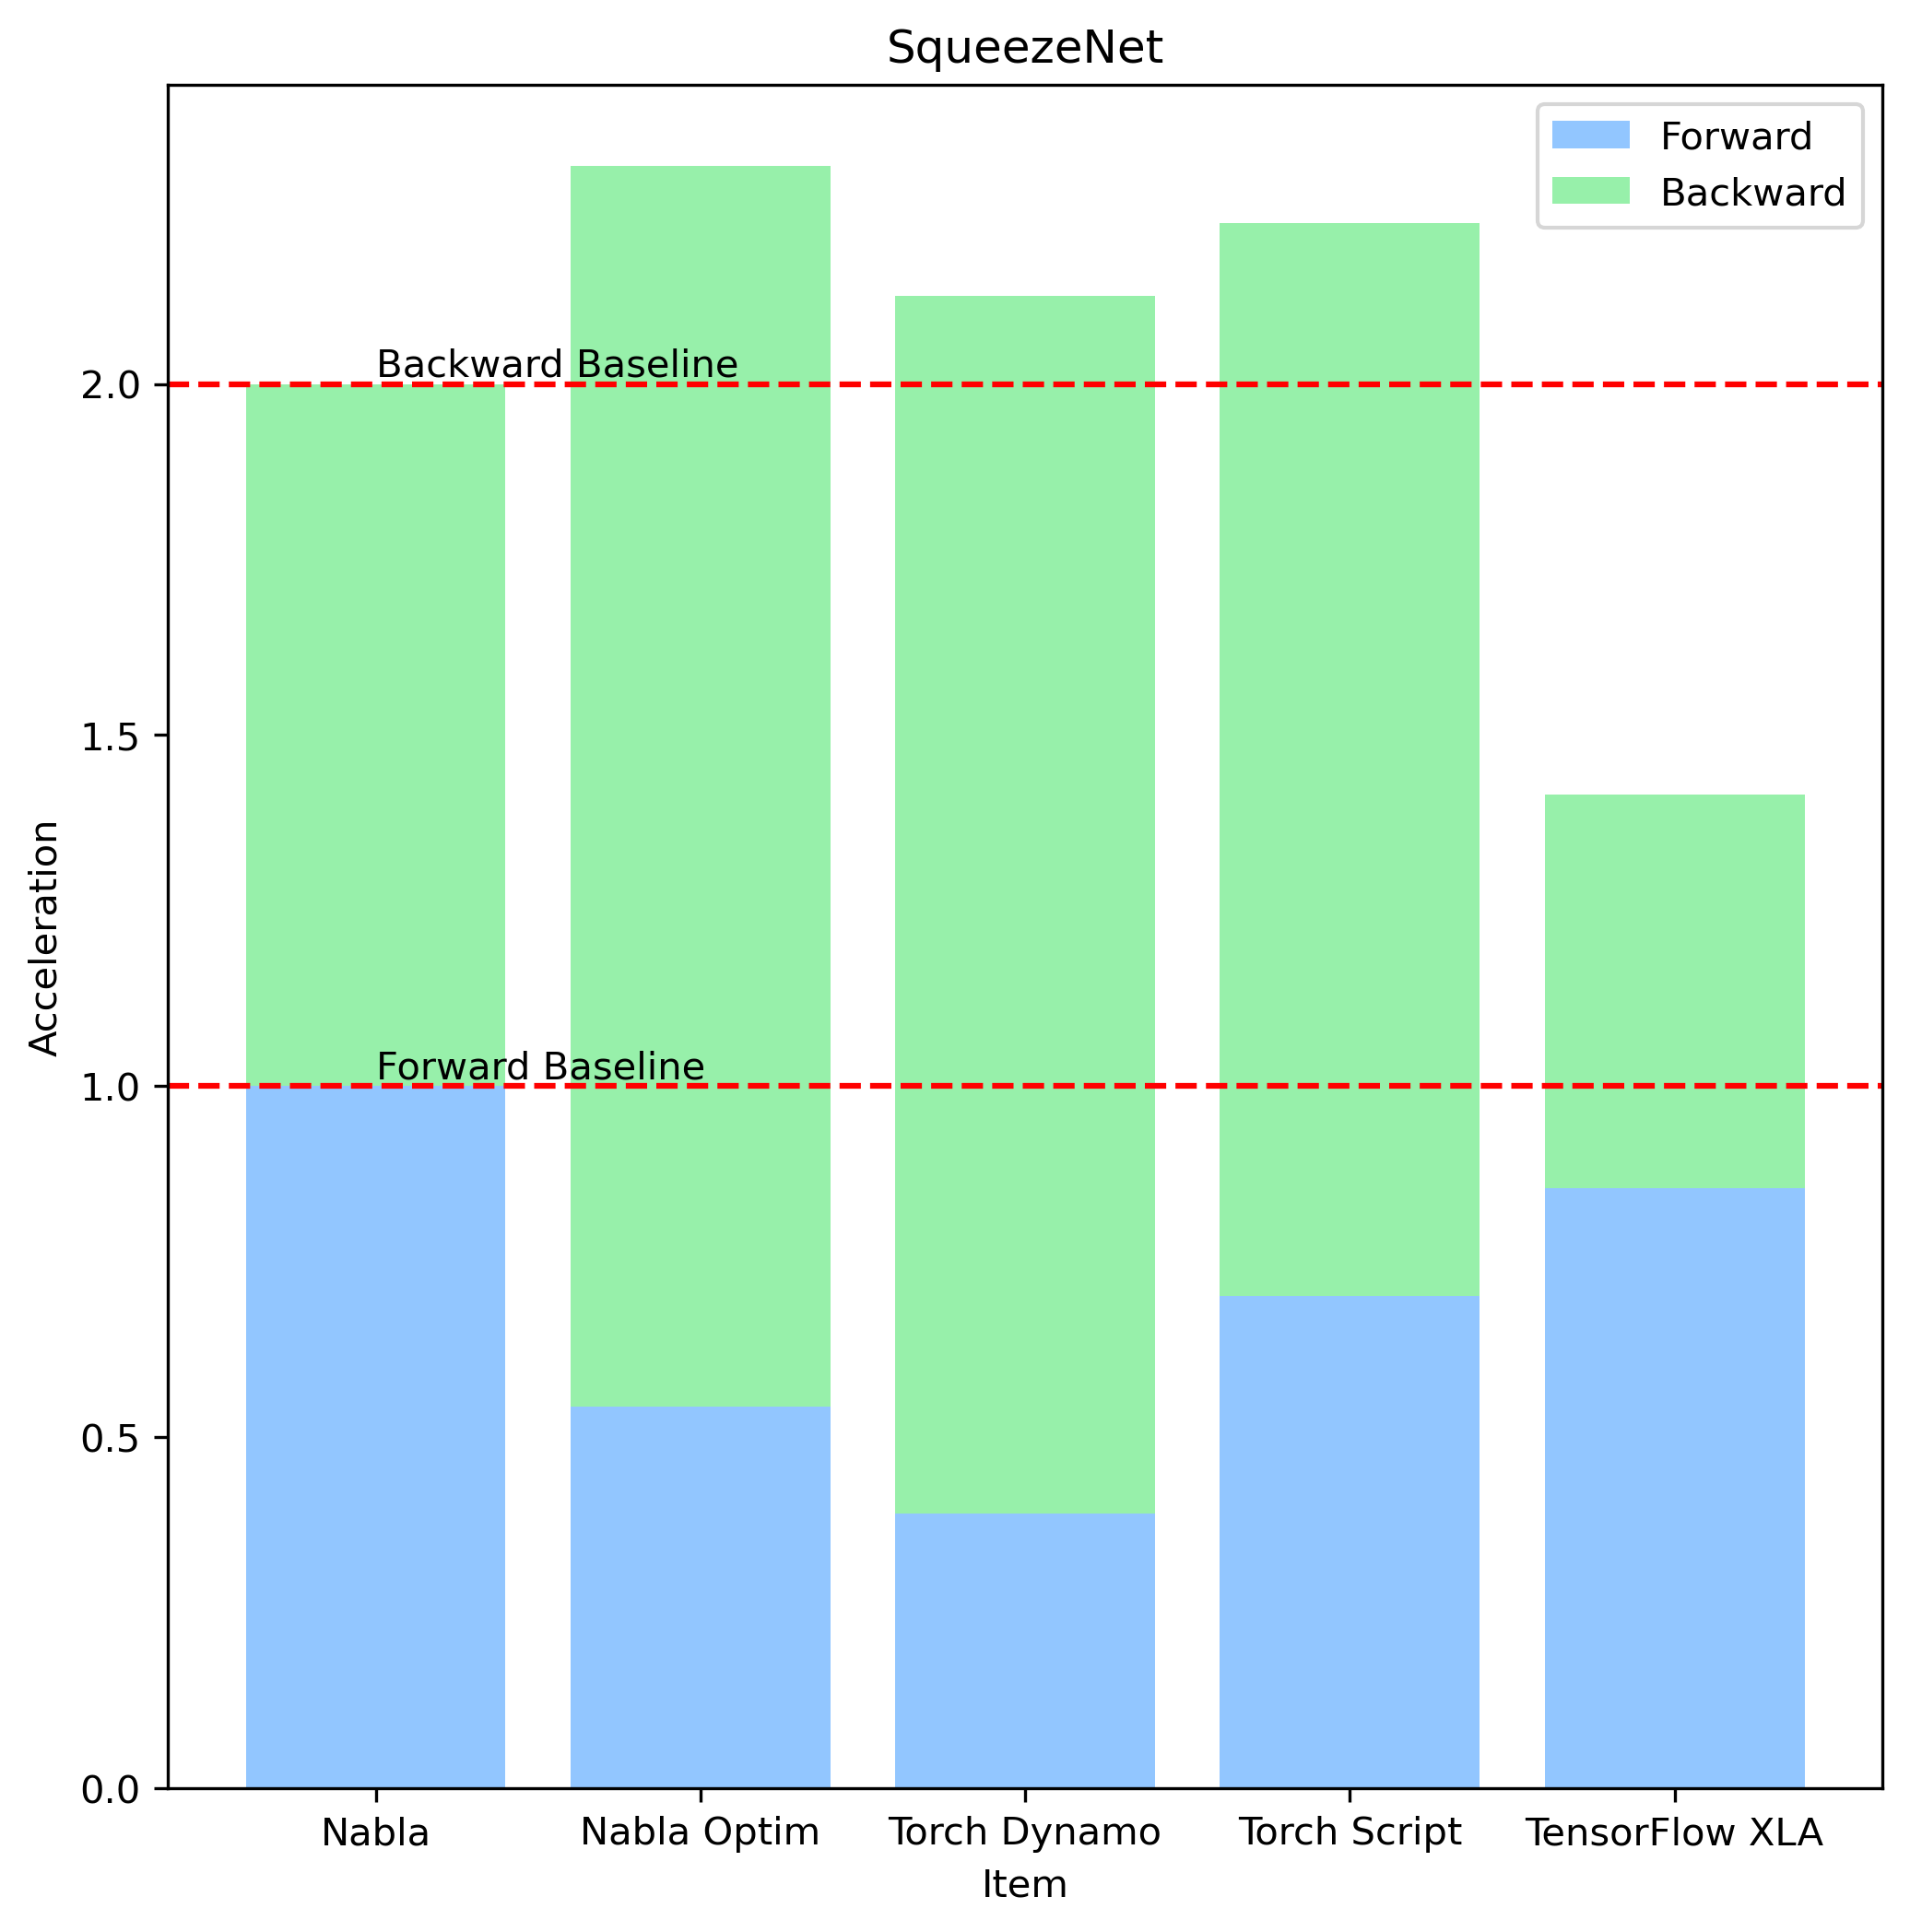

In [8]:
MODEL = "SqueezeNet"
PATH = f"{ROOT}/{MODEL.lower()}/"
torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

dfs = [torch2, torch1, tf]

for df in dfs:
    df.drop(
        columns="Unnamed: 0", inplace=True
    )
    df.drop(
        df[df["pass"] == "Full"].index, inplace=True
    )

torch2, torch1, tf = dfs

torch1.at[0, "item"] = "Torch Script"
torch1.at[3, "item"] = "Torch Script"

f_base, b_base, fo, bo = 0, 0, 0, 0
dfs = [torch2, torch1, tf]

for df in dfs:
    f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
    b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
    fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
    bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]

nabla_df = pd.DataFrame({
    "time": [f_base, b_base, fo, bo],
    "pass": ["Forward", "Backward"] * 2,
    "item": ["Nabla"] * 2 + ["Nabla Optim"] * 2
}, index=[0] * 4)
nabla_df

for df in dfs:
    nabla_df = pd.concat([
        nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
    ])
    
nabla_df.style.hide(axis="index")
f = nabla_df[nabla_df["pass"] == "Forward"]
b = nabla_df[nabla_df["pass"] == "Backward"]
f["acceleration"] = f_base / f["time"]
b["acceleration"] = b_base / b["time"]

items = ["Nabla", "Nabla Optim", "Torch Dynamo", "Torch Script", "TensorFlow XLA"]
plt.figure(dpi=300, figsize=(8, 8))

plt.bar(items, f["acceleration"], label="Forward")
plt.bar(items, b["acceleration"], label="Backward", bottom=f["acceleration"])

plt.xlabel("Item")
plt.ylabel("Acceleration")
plt.title(f"{MODEL}")
plt.legend()

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Forward Baseline", ha="left", va="bottom")
plt.axhline(2, color="red", linestyle="--", label="Baseline")
plt.text(0, 2, "Backward Baseline", ha="left", va="bottom")

print_time()

## VGG11

Model: VGG11
Forward:
  55.02460860647261
  70.06408216742177
  44.668853702023625
  62.46191629208624
  57.94582346454263
Backward:
  75.20004673860967
  18.68315860318641
  171.34165581315756
  162.88061127997935
  329.8374484013766


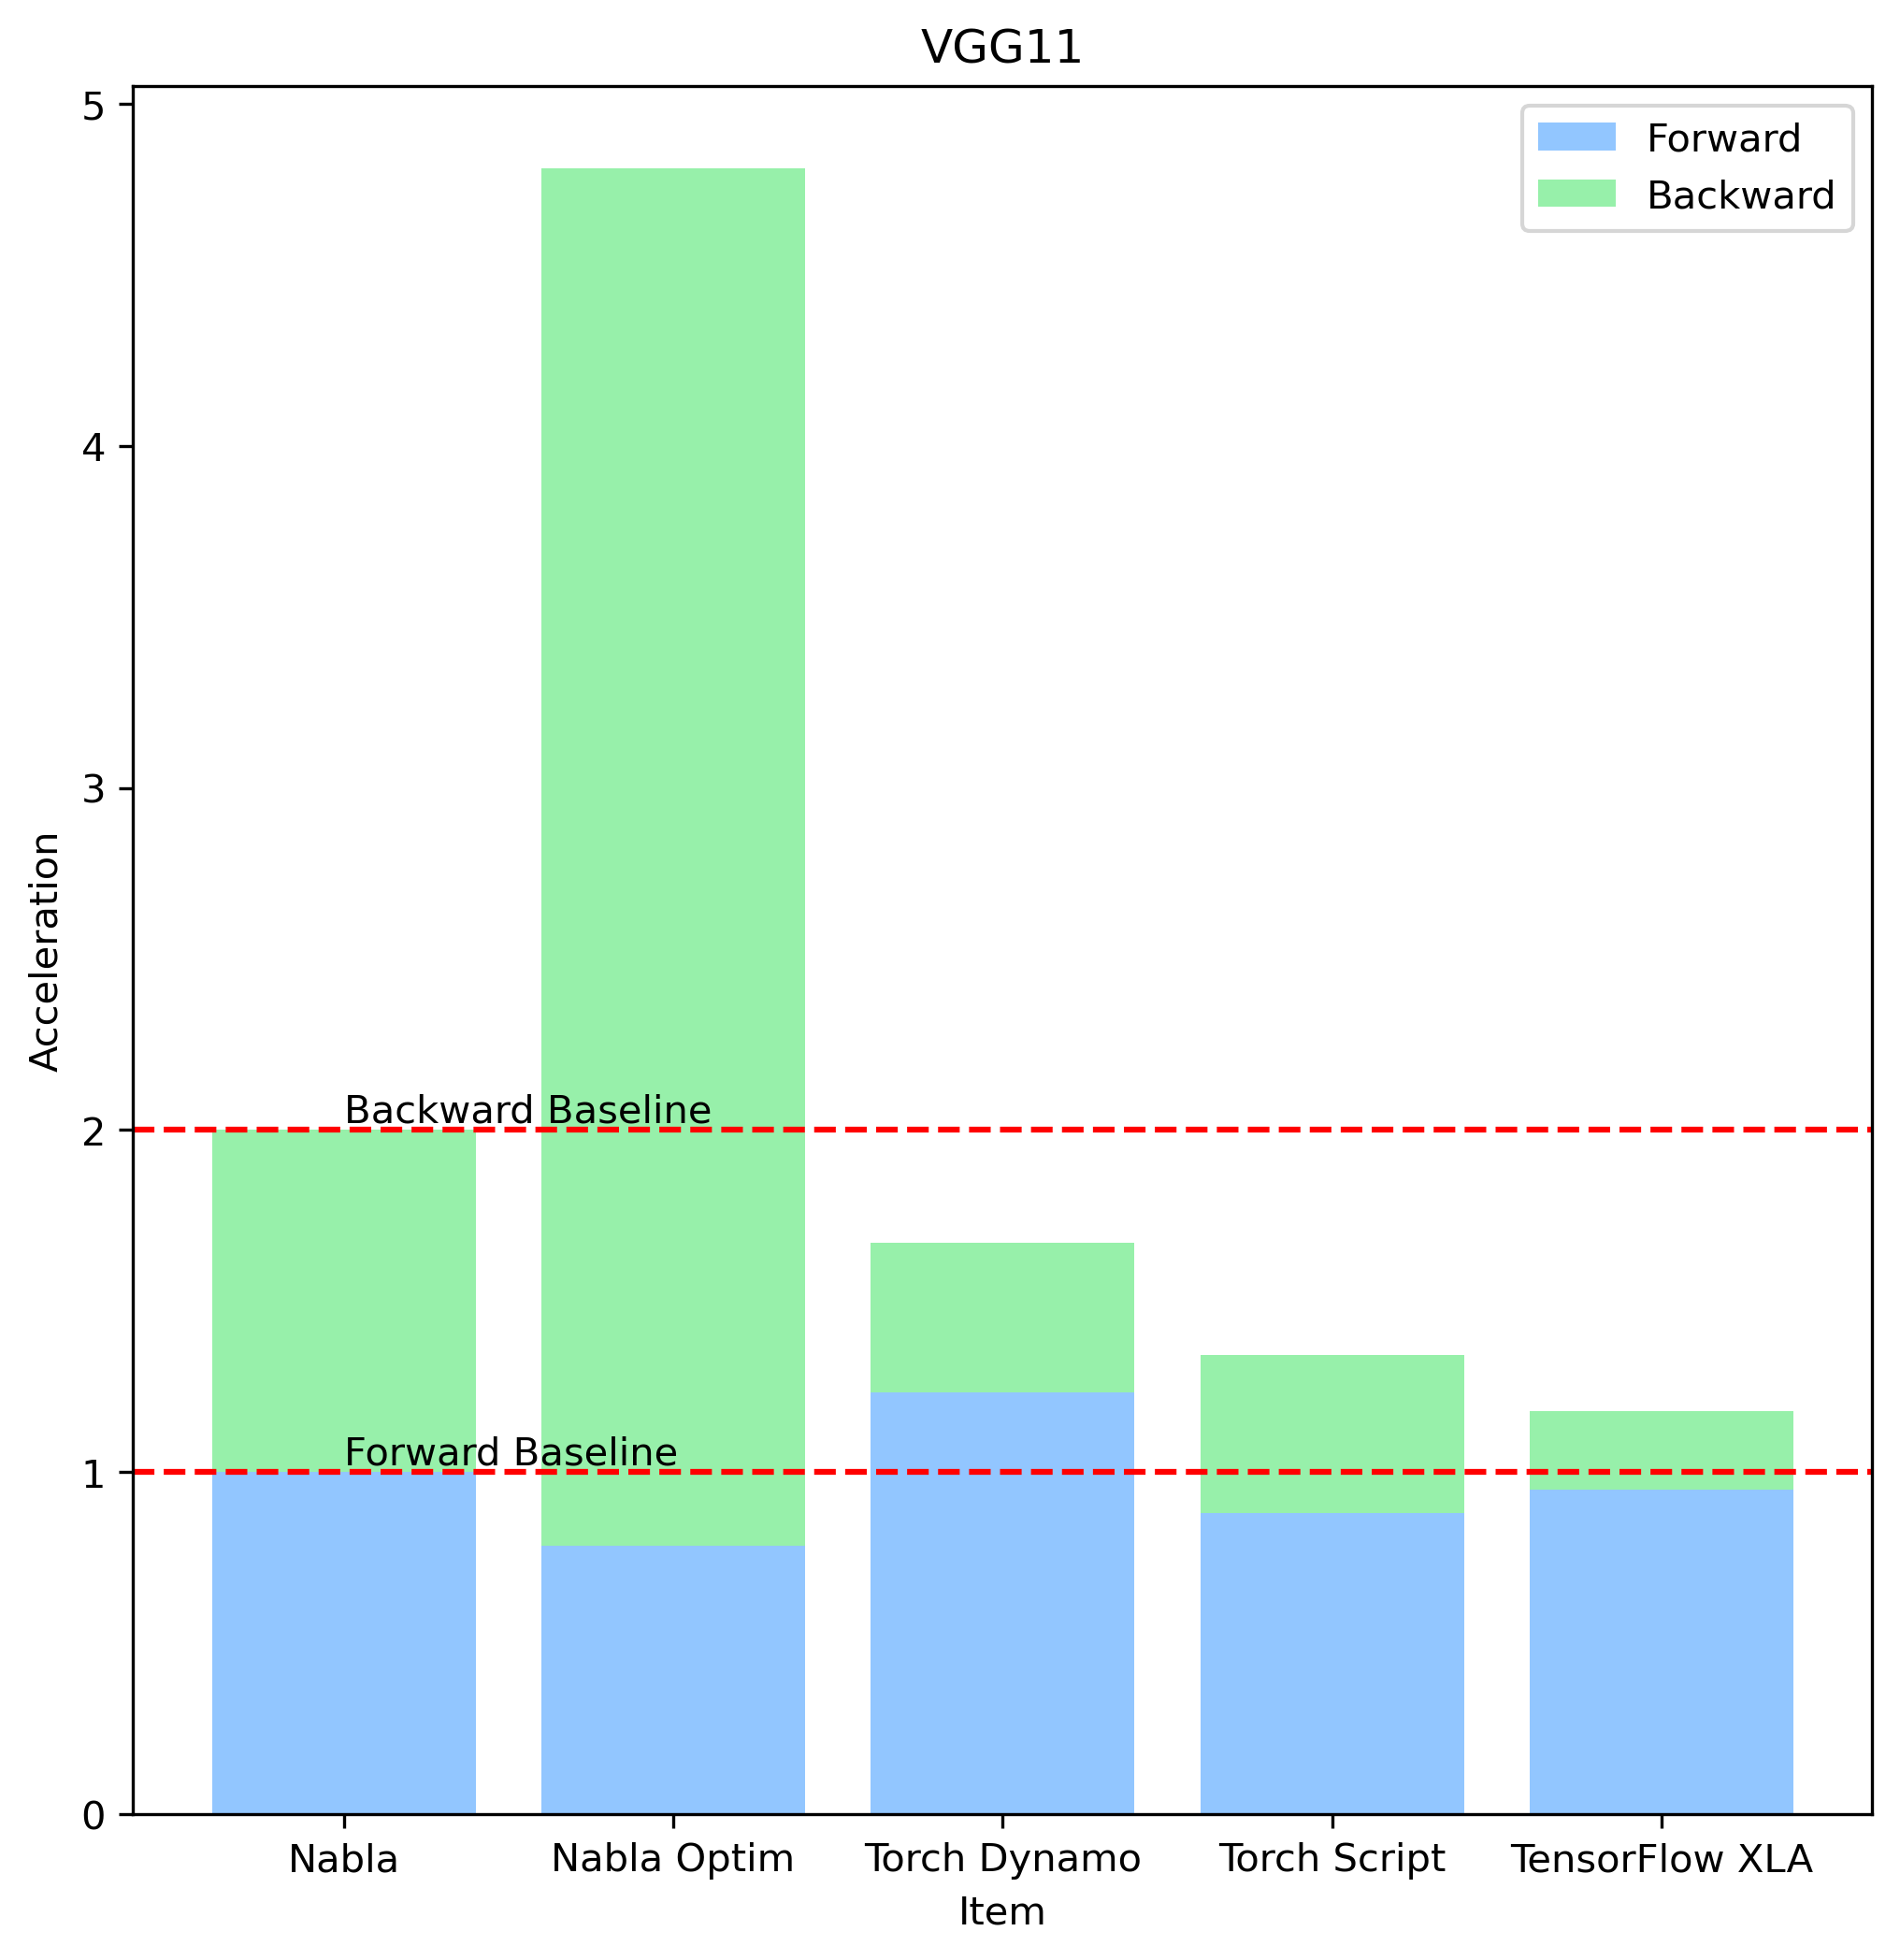

In [9]:
MODEL = "VGG11"
PATH = f"{ROOT}/{MODEL.lower()}/"
torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

dfs = [torch2, torch1, tf]

for df in dfs:
    df.drop(
        columns="Unnamed: 0", inplace=True
    )
    df.drop(
        df[df["pass"] == "Full"].index, inplace=True
    )

torch2, torch1, tf = dfs

torch1.at[0, "item"] = "Torch Script"
torch1.at[3, "item"] = "Torch Script"

f_base, b_base, fo, bo = 0, 0, 0, 0
dfs = [torch2, torch1, tf]

for df in dfs:
    f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
    b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
    fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
    bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]

nabla_df = pd.DataFrame({
    "time": [f_base, b_base, fo, bo],
    "pass": ["Forward", "Backward"] * 2,
    "item": ["Nabla"] * 2 + ["Nabla Optim"] * 2
}, index=[0] * 4)
nabla_df

for df in dfs:
    nabla_df = pd.concat([
        nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
    ])
    
nabla_df.style.hide(axis="index")
f = nabla_df[nabla_df["pass"] == "Forward"]
b = nabla_df[nabla_df["pass"] == "Backward"]
f["acceleration"] = f_base / f["time"]
b["acceleration"] = b_base / b["time"]

items = ["Nabla", "Nabla Optim", "Torch Dynamo", "Torch Script", "TensorFlow XLA"]
plt.figure(dpi=300, figsize=(8, 8))

plt.bar(items, f["acceleration"], label="Forward")
plt.bar(items, b["acceleration"], label="Backward", bottom=f["acceleration"])

plt.xlabel("Item")
plt.ylabel("Acceleration")
plt.title(f"{MODEL}")
plt.legend()

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Forward Baseline", ha="left", va="bottom")
plt.axhline(2, color="red", linestyle="--", label="Baseline")
plt.text(0, 2, "Backward Baseline", ha="left", va="bottom")

print_time()

## VGG13

Model: VGG13
Forward:
  80.0930972242107
  101.84661577145259
  52.778166718780994
  74.91711889393628
  69.77602832950652
Backward:
  110.15657753062744
  28.021220449979108
  190.86104535497725
  181.87015659175813
  382.23544656299055


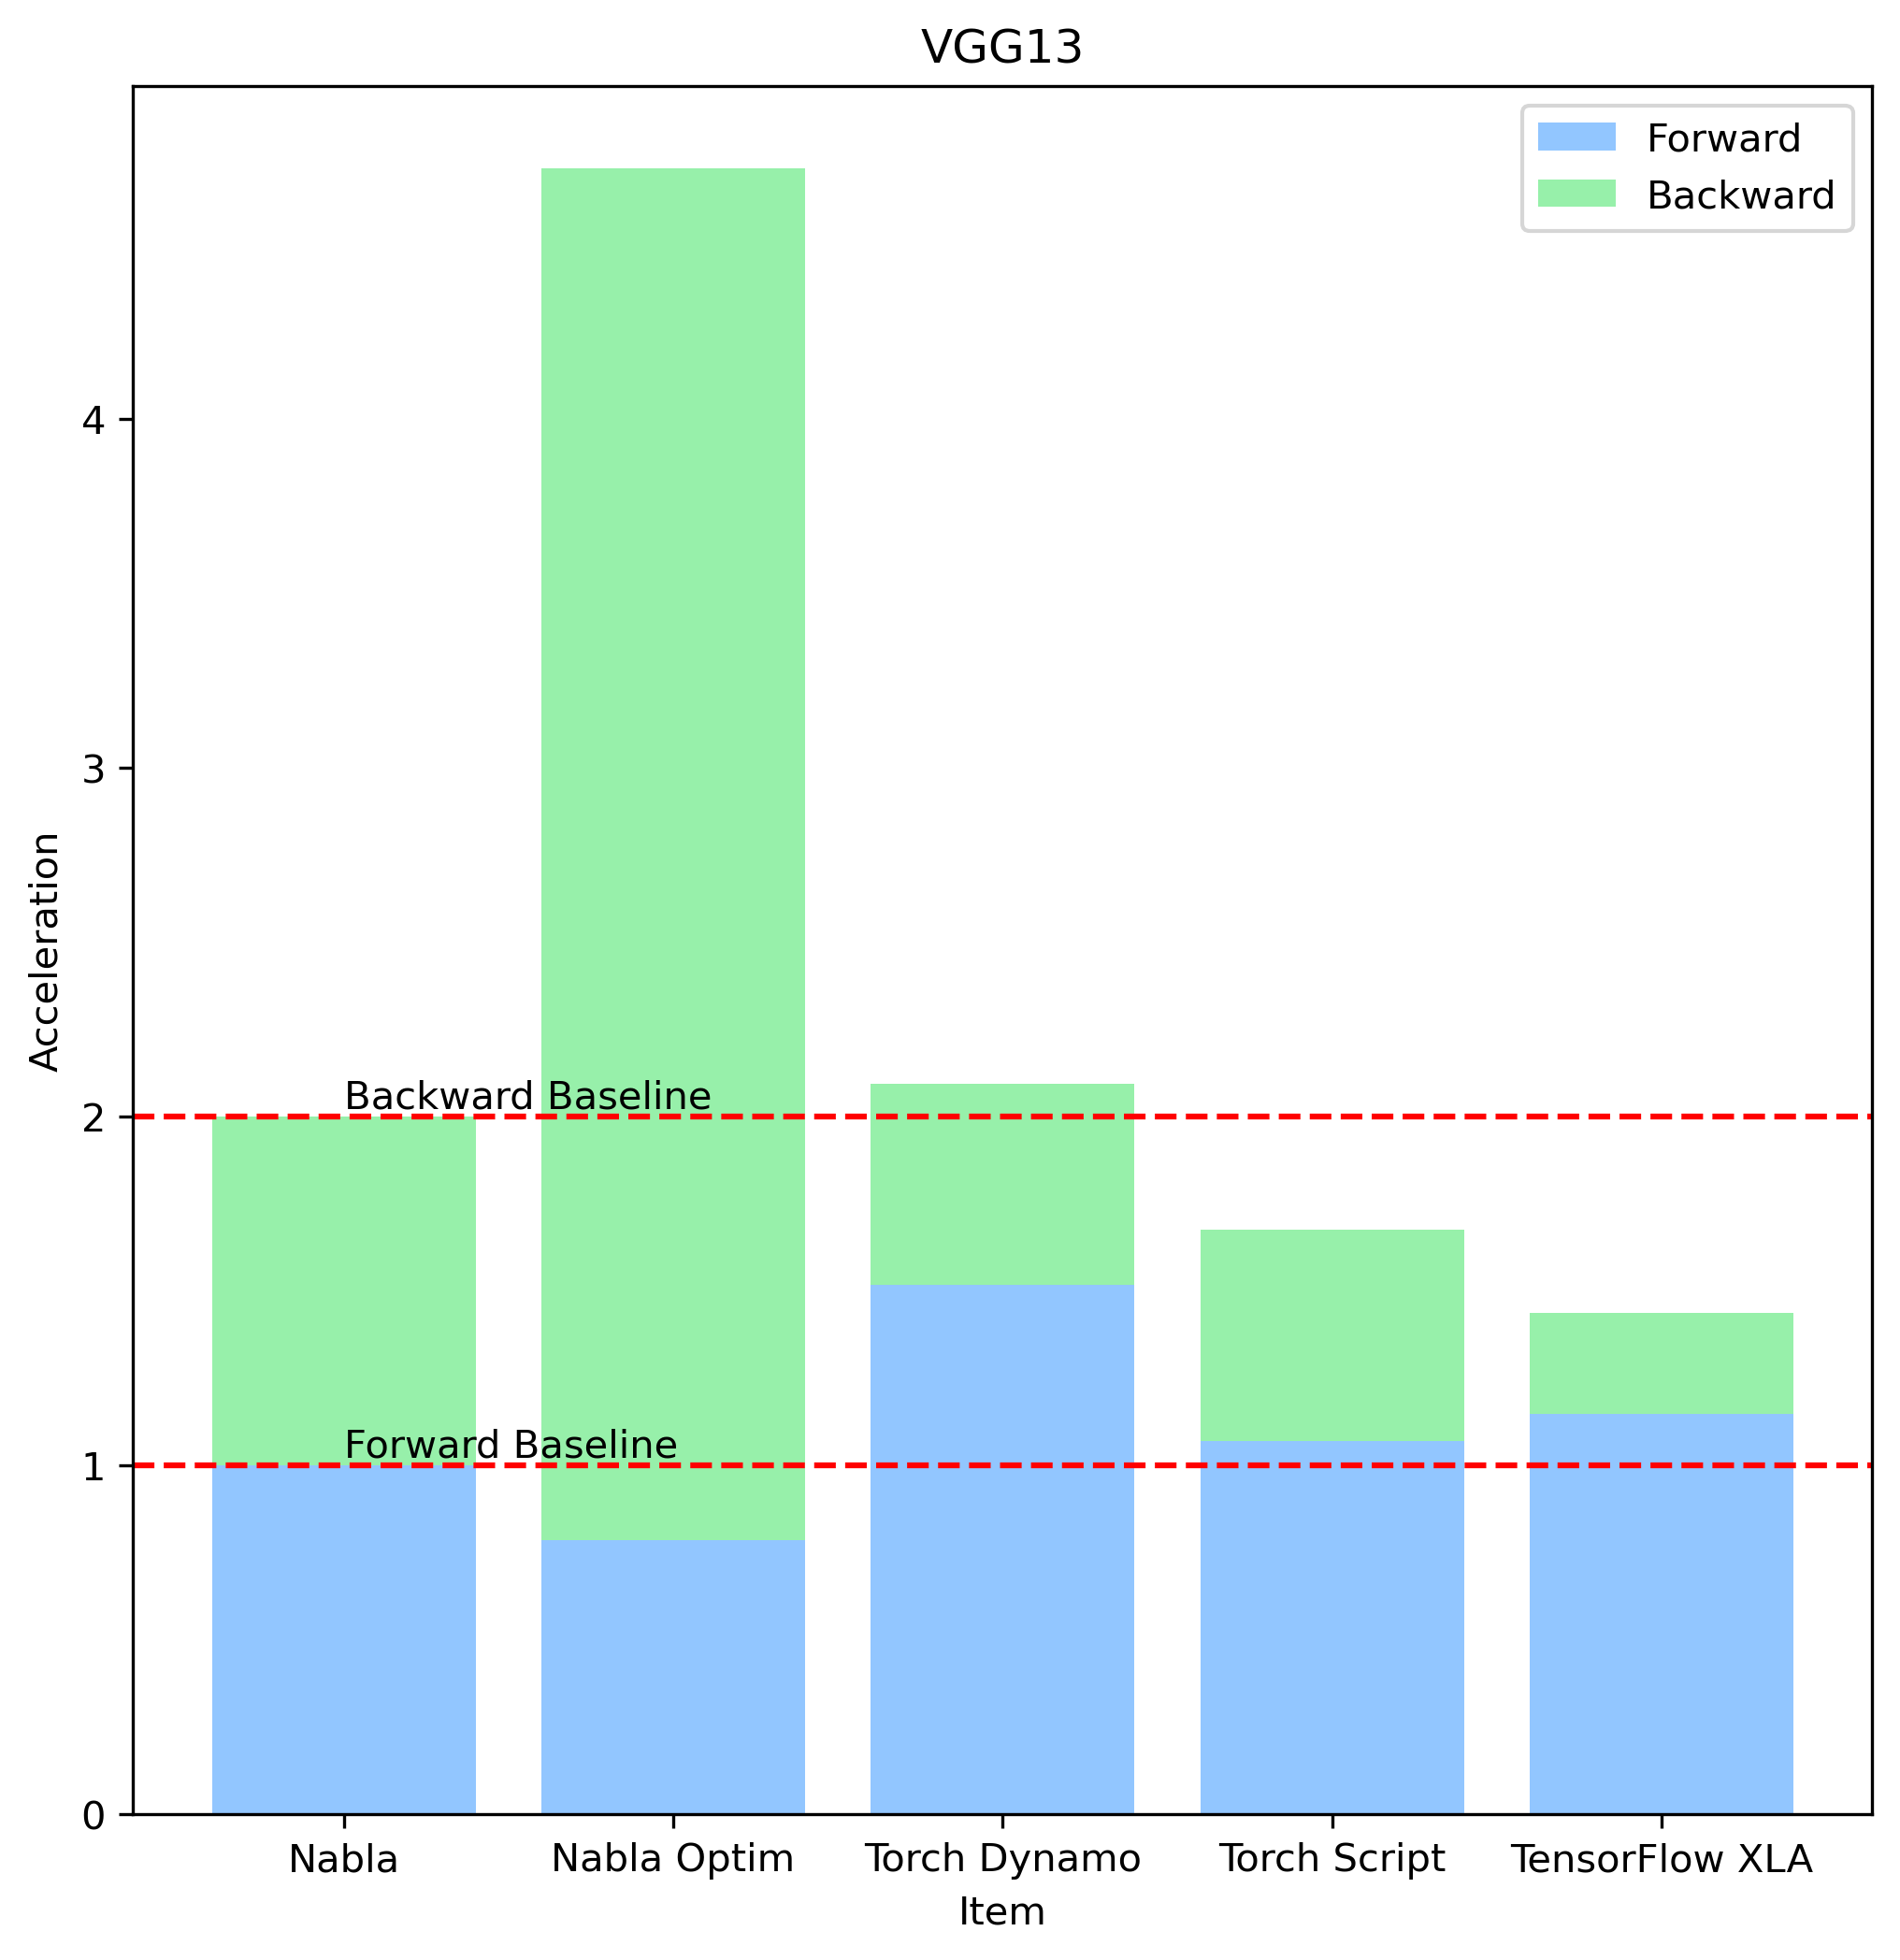

In [10]:
MODEL = "VGG13"
PATH = f"{ROOT}/{MODEL.lower()}/"
torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

dfs = [torch2, torch1, tf]

for df in dfs:
    df.drop(
        columns="Unnamed: 0", inplace=True
    )
    df.drop(
        df[df["pass"] == "Full"].index, inplace=True
    )

torch2, torch1, tf = dfs

torch1.at[0, "item"] = "Torch Script"
torch1.at[3, "item"] = "Torch Script"

f_base, b_base, fo, bo = 0, 0, 0, 0
dfs = [torch2, torch1, tf]

for df in dfs:
    f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
    b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
    fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
    bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]

nabla_df = pd.DataFrame({
    "time": [f_base, b_base, fo, bo],
    "pass": ["Forward", "Backward"] * 2,
    "item": ["Nabla"] * 2 + ["Nabla Optim"] * 2
}, index=[0] * 4)
nabla_df

for df in dfs:
    nabla_df = pd.concat([
        nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
    ])
    
nabla_df.style.hide(axis="index")
f = nabla_df[nabla_df["pass"] == "Forward"]
b = nabla_df[nabla_df["pass"] == "Backward"]
f["acceleration"] = f_base / f["time"]
b["acceleration"] = b_base / b["time"]

items = ["Nabla", "Nabla Optim", "Torch Dynamo", "Torch Script", "TensorFlow XLA"]
plt.figure(dpi=300, figsize=(8, 8))

plt.bar(items, f["acceleration"], label="Forward")
plt.bar(items, b["acceleration"], label="Backward", bottom=f["acceleration"])

plt.xlabel("Item")
plt.ylabel("Acceleration")
plt.title(f"{MODEL}")
plt.legend()

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Forward Baseline", ha="left", va="bottom")
plt.axhline(2, color="red", linestyle="--", label="Baseline")
plt.text(0, 2, "Backward Baseline", ha="left", va="bottom")

print_time()

## VGG16

Model: VGG16
Forward:
  105.05839749860267
  130.3248970552037
  63.71305027976632
  76.00271984934807
  81.79041154682636
Backward:
  137.88774790863195
  28.676886716857553
  228.3555228356272
  192.4608720652759
  387.37062592059374


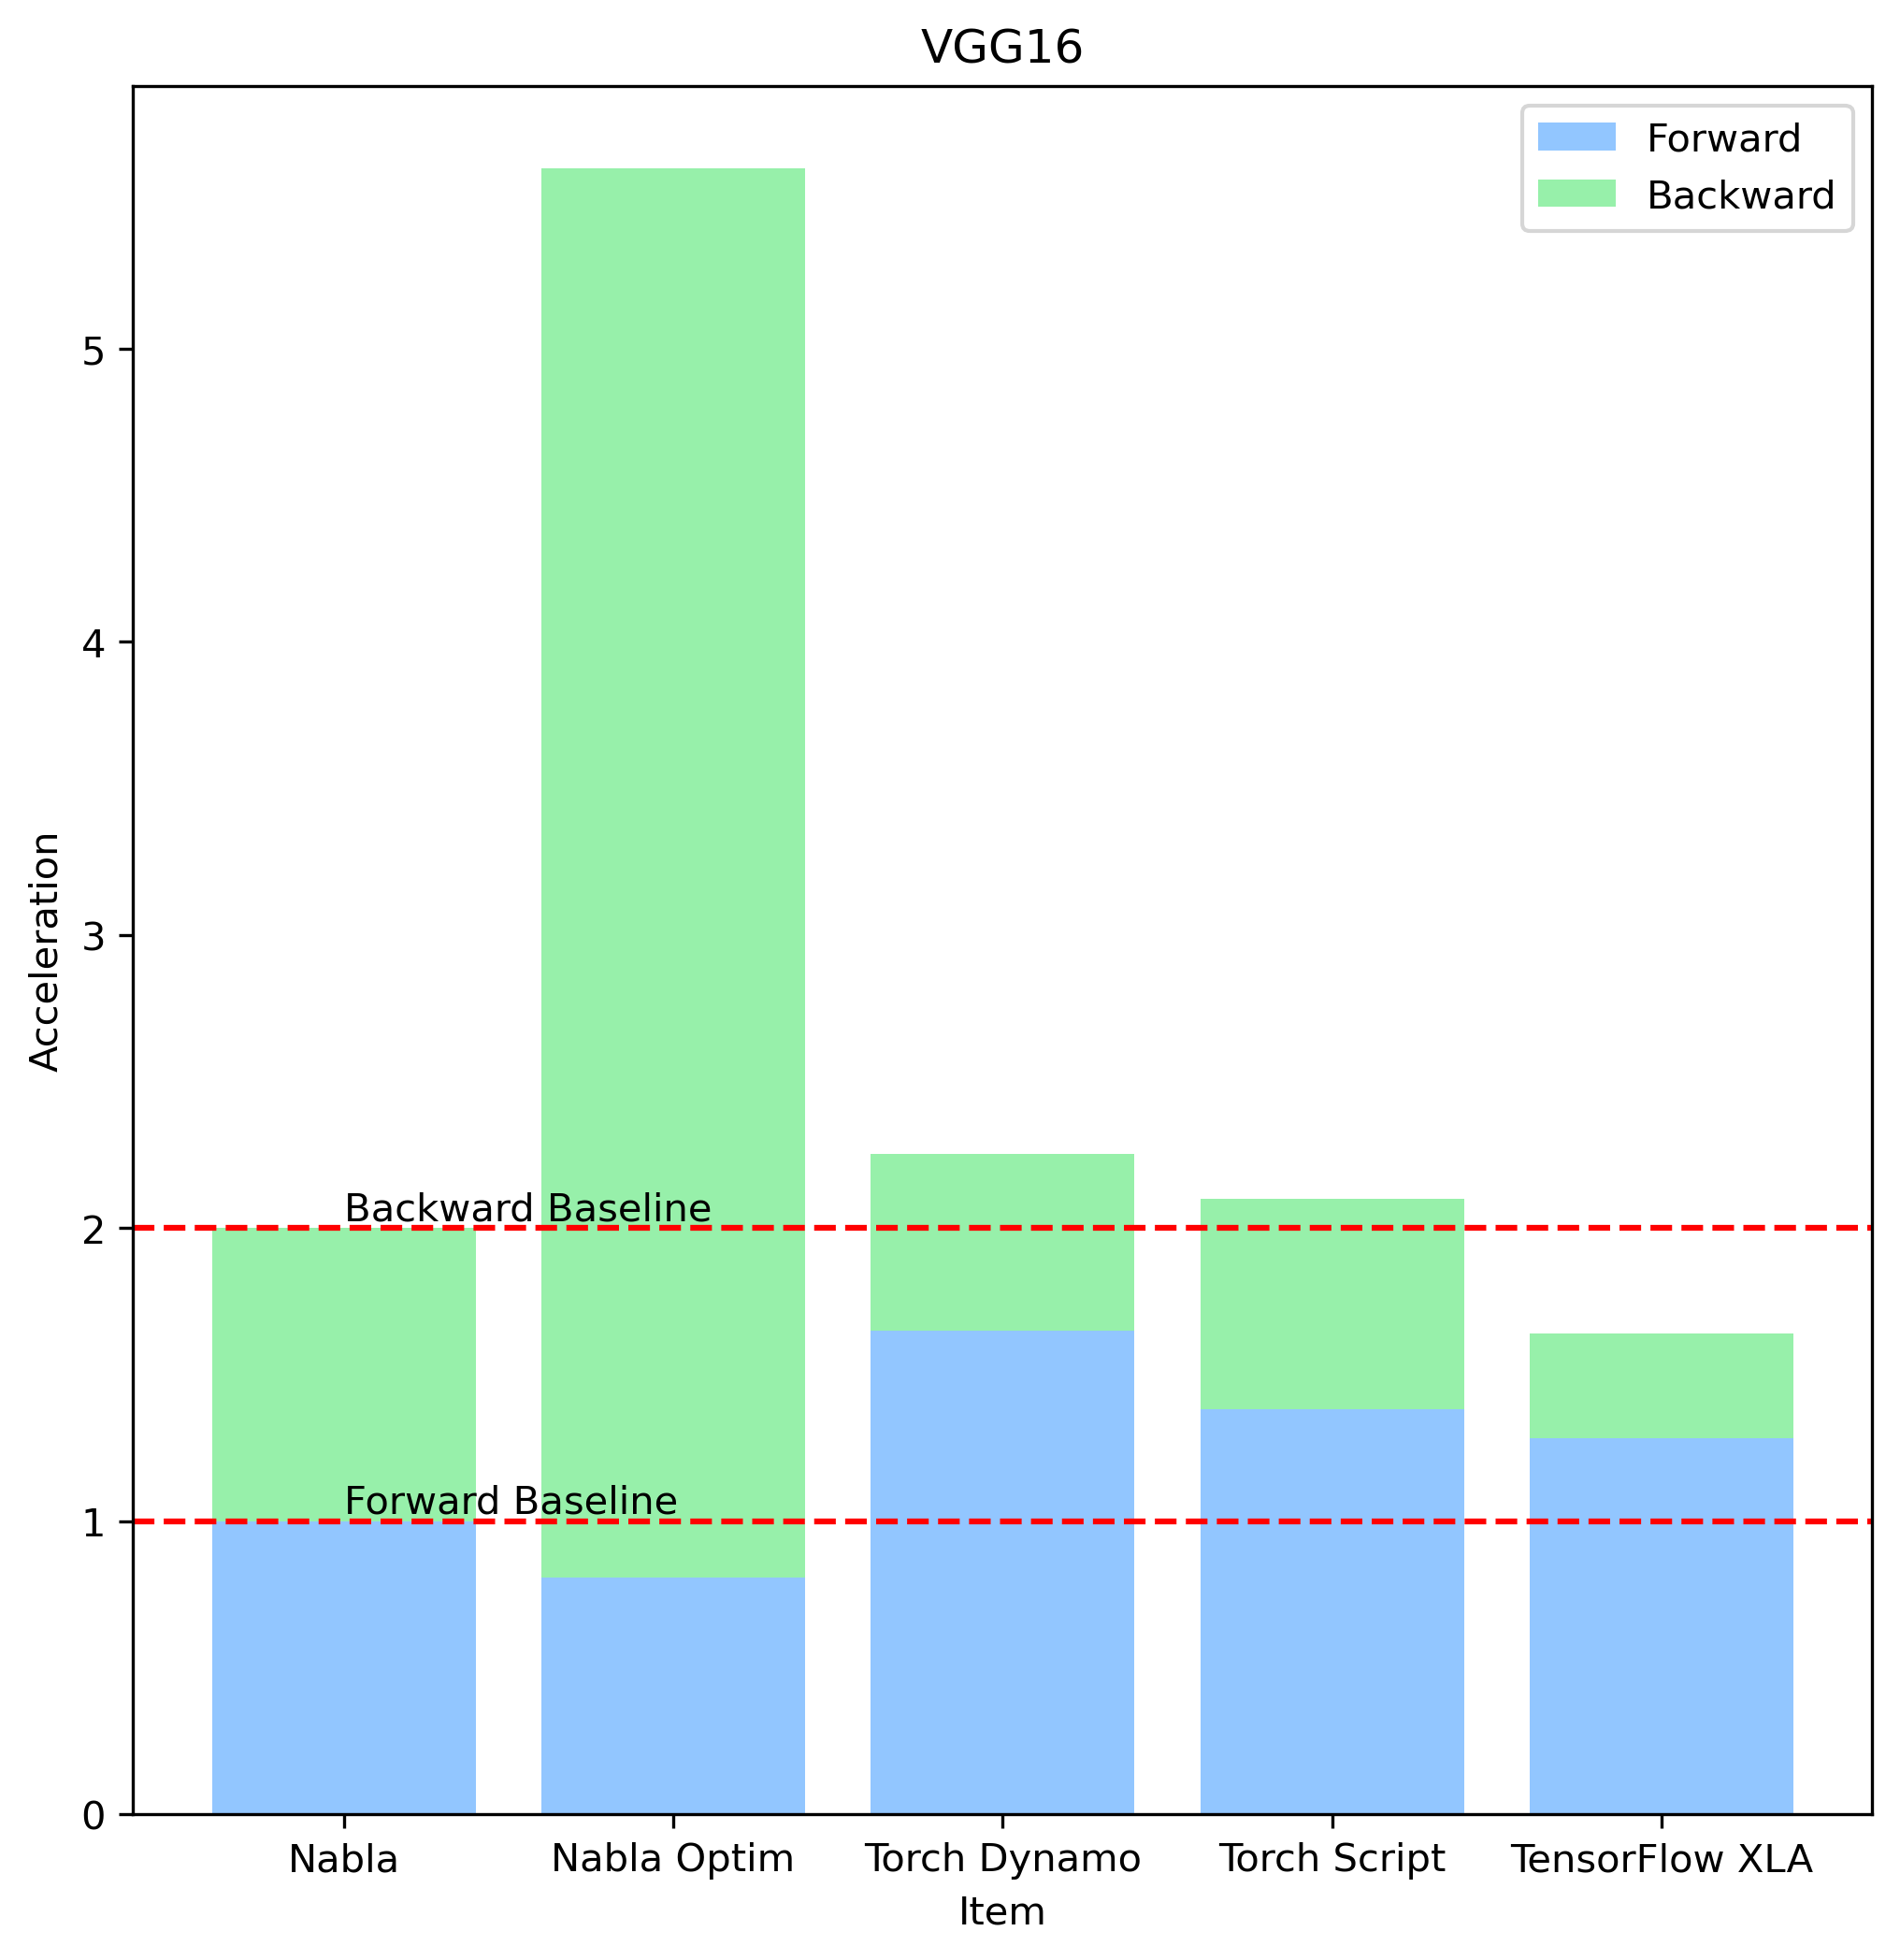

In [11]:
MODEL = "VGG16"
PATH = f"{ROOT}/{MODEL.lower()}/"
torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

dfs = [torch2, torch1, tf]

for df in dfs:
    df.drop(
        columns="Unnamed: 0", inplace=True
    )
    df.drop(
        df[df["pass"] == "Full"].index, inplace=True
    )

torch2, torch1, tf = dfs

torch1.at[0, "item"] = "Torch Script"
torch1.at[3, "item"] = "Torch Script"

f_base, b_base, fo, bo = 0, 0, 0, 0
dfs = [torch2, torch1, tf]

for df in dfs:
    f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
    b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
    fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
    bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]

nabla_df = pd.DataFrame({
    "time": [f_base, b_base, fo, bo],
    "pass": ["Forward", "Backward"] * 2,
    "item": ["Nabla"] * 2 + ["Nabla Optim"] * 2
}, index=[0] * 4)
nabla_df

for df in dfs:
    nabla_df = pd.concat([
        nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
    ])
    
nabla_df.style.hide(axis="index")
f = nabla_df[nabla_df["pass"] == "Forward"]
b = nabla_df[nabla_df["pass"] == "Backward"]
f["acceleration"] = f_base / f["time"]
b["acceleration"] = b_base / b["time"]

items = ["Nabla", "Nabla Optim", "Torch Dynamo", "Torch Script", "TensorFlow XLA"]
plt.figure(dpi=300, figsize=(8, 8))

plt.bar(items, f["acceleration"], label="Forward")
plt.bar(items, b["acceleration"], label="Backward", bottom=f["acceleration"])

plt.xlabel("Item")
plt.ylabel("Acceleration")
plt.title(f"{MODEL}")
plt.legend()

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Forward Baseline", ha="left", va="bottom")
plt.axhline(2, color="red", linestyle="--", label="Baseline")
plt.text(0, 2, "Backward Baseline", ha="left", va="bottom")

print_time()

## VGG19

Model: VGG19
Forward:
  129.86353526823223
  157.6539182011038
  74.89553074352443
  83.20041487924755
  97.21335681155324
Backward:
  165.42022748229405
  27.455405555665493
  226.5377716254443
  204.5096652582288
  443.357243174687


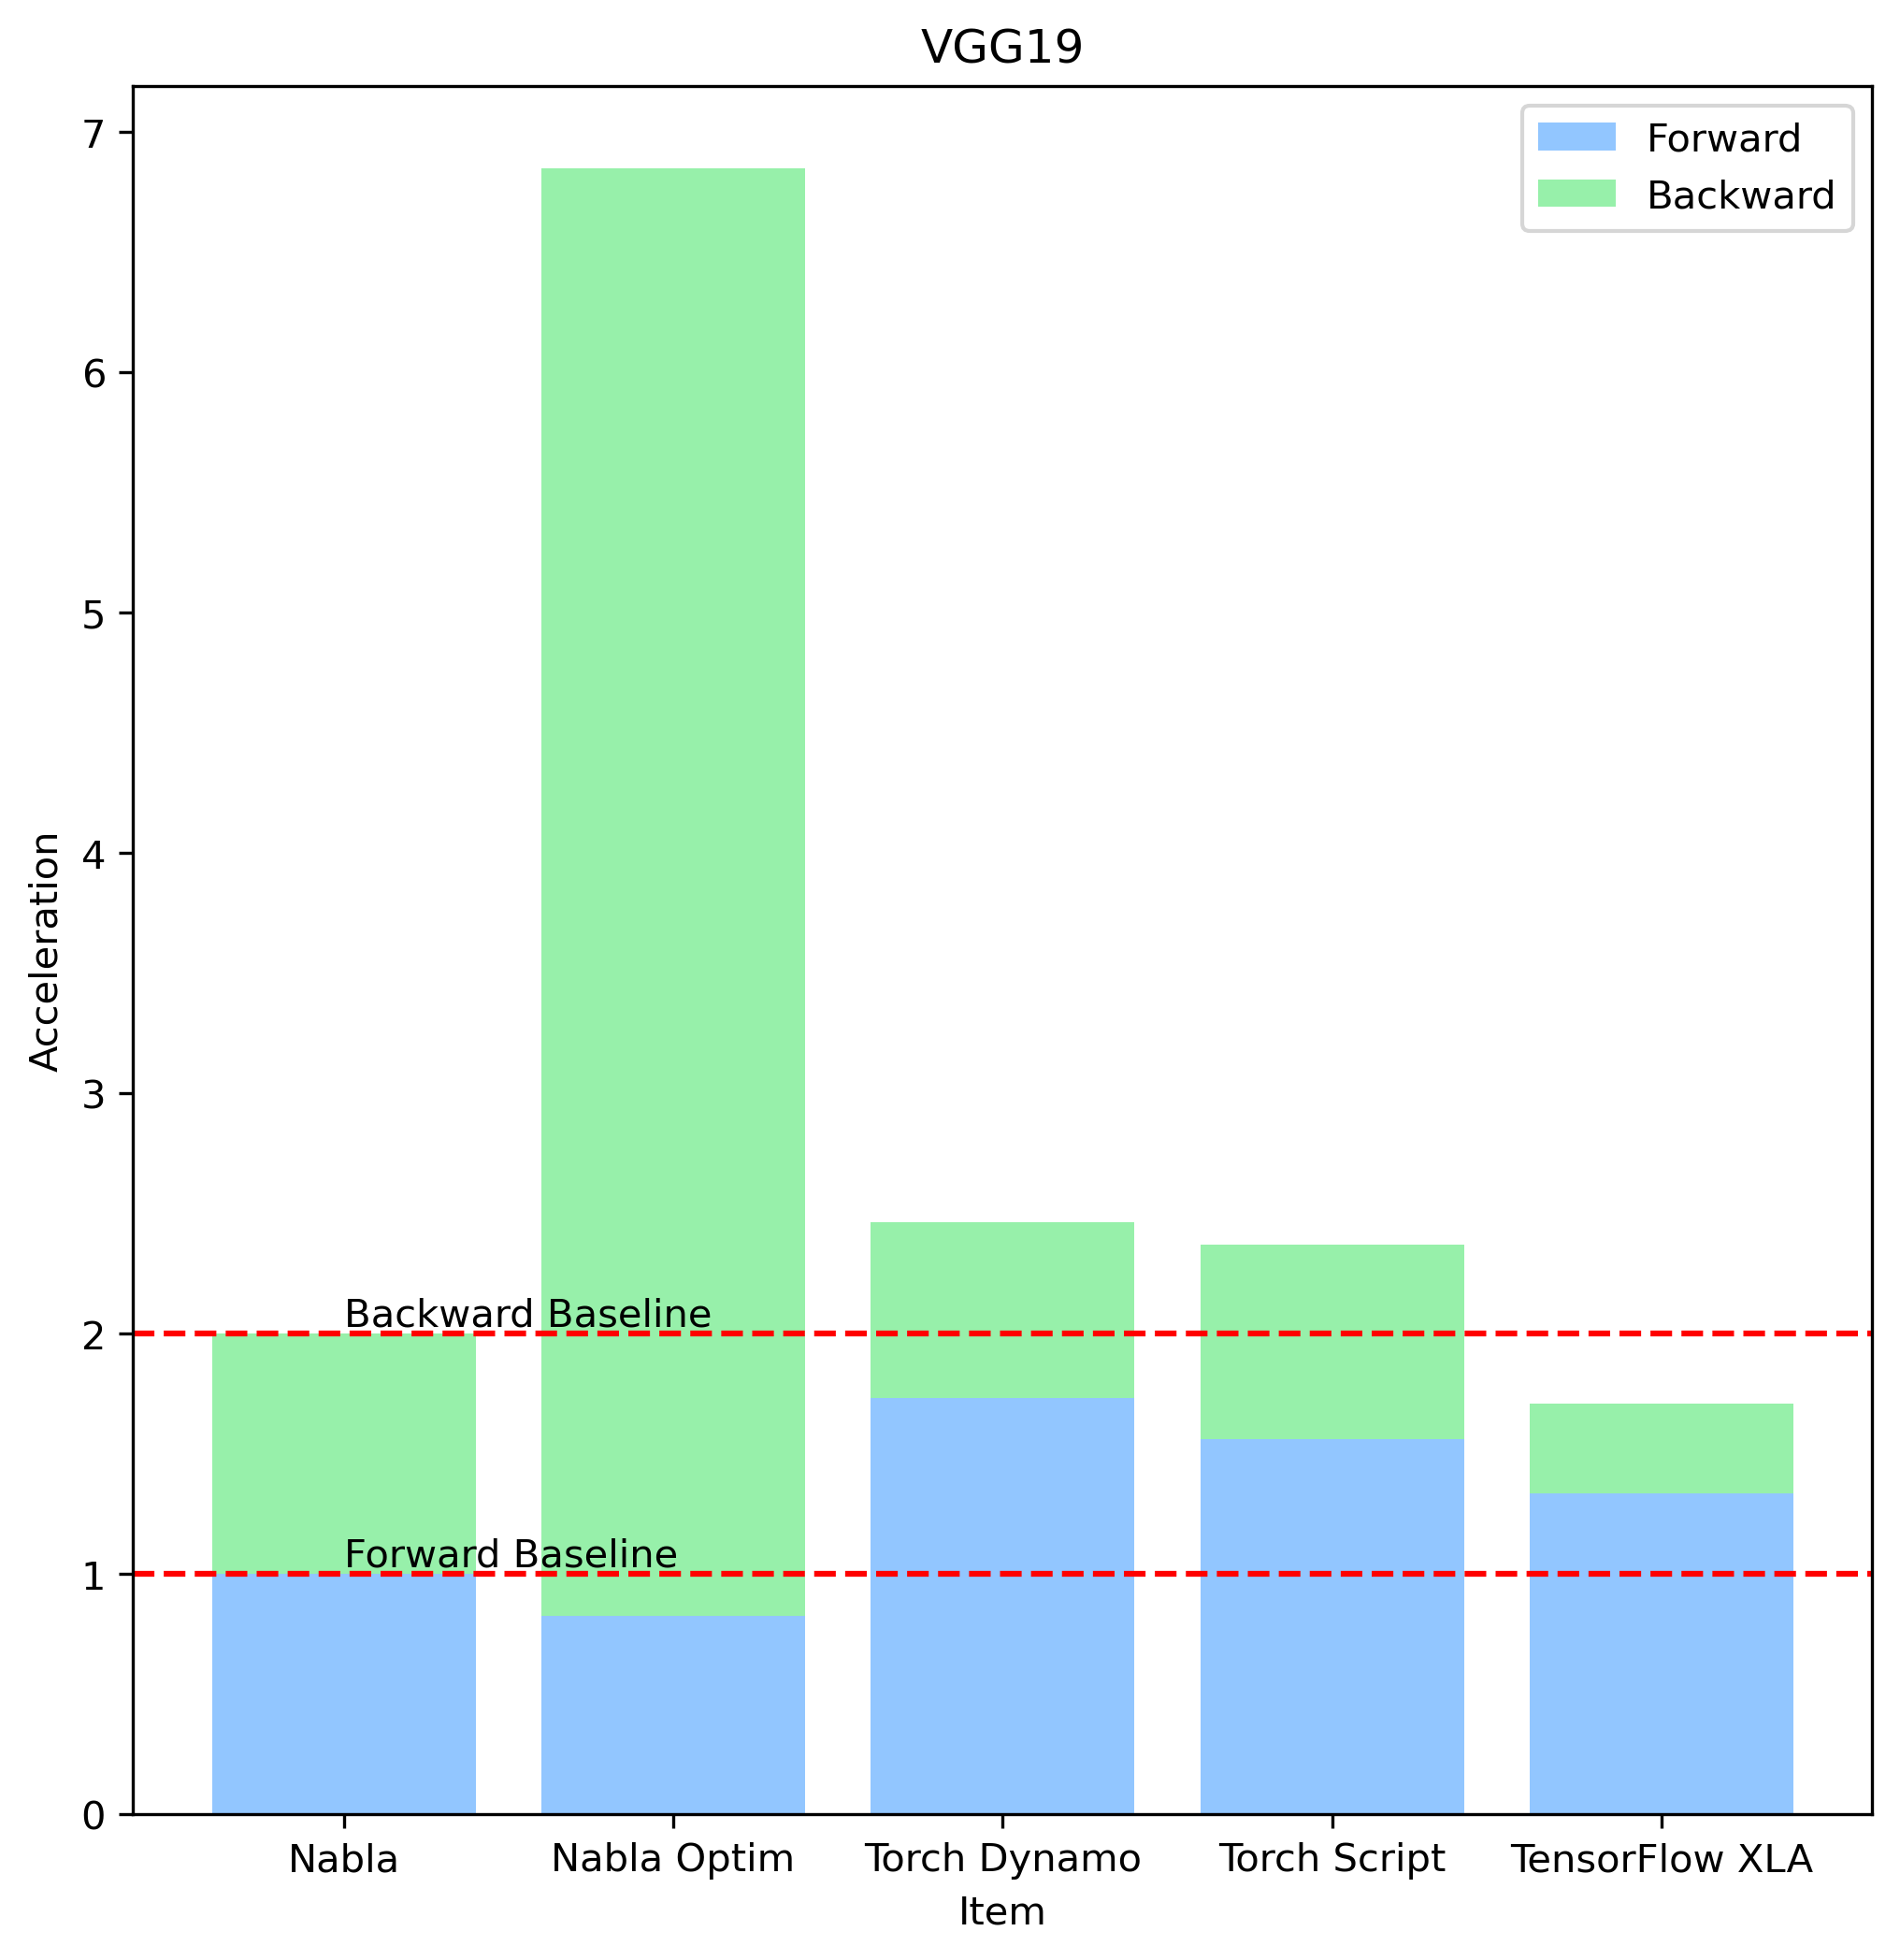

In [12]:
MODEL = "VGG19"
PATH = f"{ROOT}/{MODEL.lower()}/"
torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

dfs = [torch2, torch1, tf]

for df in dfs:
    df.drop(
        columns="Unnamed: 0", inplace=True
    )
    df.drop(
        df[df["pass"] == "Full"].index, inplace=True
    )

torch2, torch1, tf = dfs

torch1.at[0, "item"] = "Torch Script"
torch1.at[3, "item"] = "Torch Script"

f_base, b_base, fo, bo = 0, 0, 0, 0
dfs = [torch2, torch1, tf]

for df in dfs:
    f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
    b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
    fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
    bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]

nabla_df = pd.DataFrame({
    "time": [f_base, b_base, fo, bo],
    "pass": ["Forward", "Backward"] * 2,
    "item": ["Nabla"] * 2 + ["Nabla Optim"] * 2
}, index=[0] * 4)
nabla_df

for df in dfs:
    nabla_df = pd.concat([
        nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
    ])
    
nabla_df.style.hide(axis="index")
f = nabla_df[nabla_df["pass"] == "Forward"]
b = nabla_df[nabla_df["pass"] == "Backward"]
f["acceleration"] = f_base / f["time"]
b["acceleration"] = b_base / b["time"]

items = ["Nabla", "Nabla Optim", "Torch Dynamo", "Torch Script", "TensorFlow XLA"]
plt.figure(dpi=300, figsize=(8, 8))

plt.bar(items, f["acceleration"], label="Forward")
plt.bar(items, b["acceleration"], label="Backward", bottom=f["acceleration"])

plt.xlabel("Item")
plt.ylabel("Acceleration")
plt.title(f"{MODEL}")
plt.legend()

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Forward Baseline", ha="left", va="bottom")
plt.axhline(2, color="red", linestyle="--", label="Baseline")
plt.text(0, 2, "Backward Baseline", ha="left", va="bottom")

print_time()

## WideResNet50

Model: WideResNet50
Forward:
  106.90521979704499
  122.49478771351278
  86.44681140780449
  142.80881435610354
  91.47986315190792
Backward:
  534.5650558639318
  401.2512382026762
  224.334678389132
  218.4961554594338
  264.0281067416072


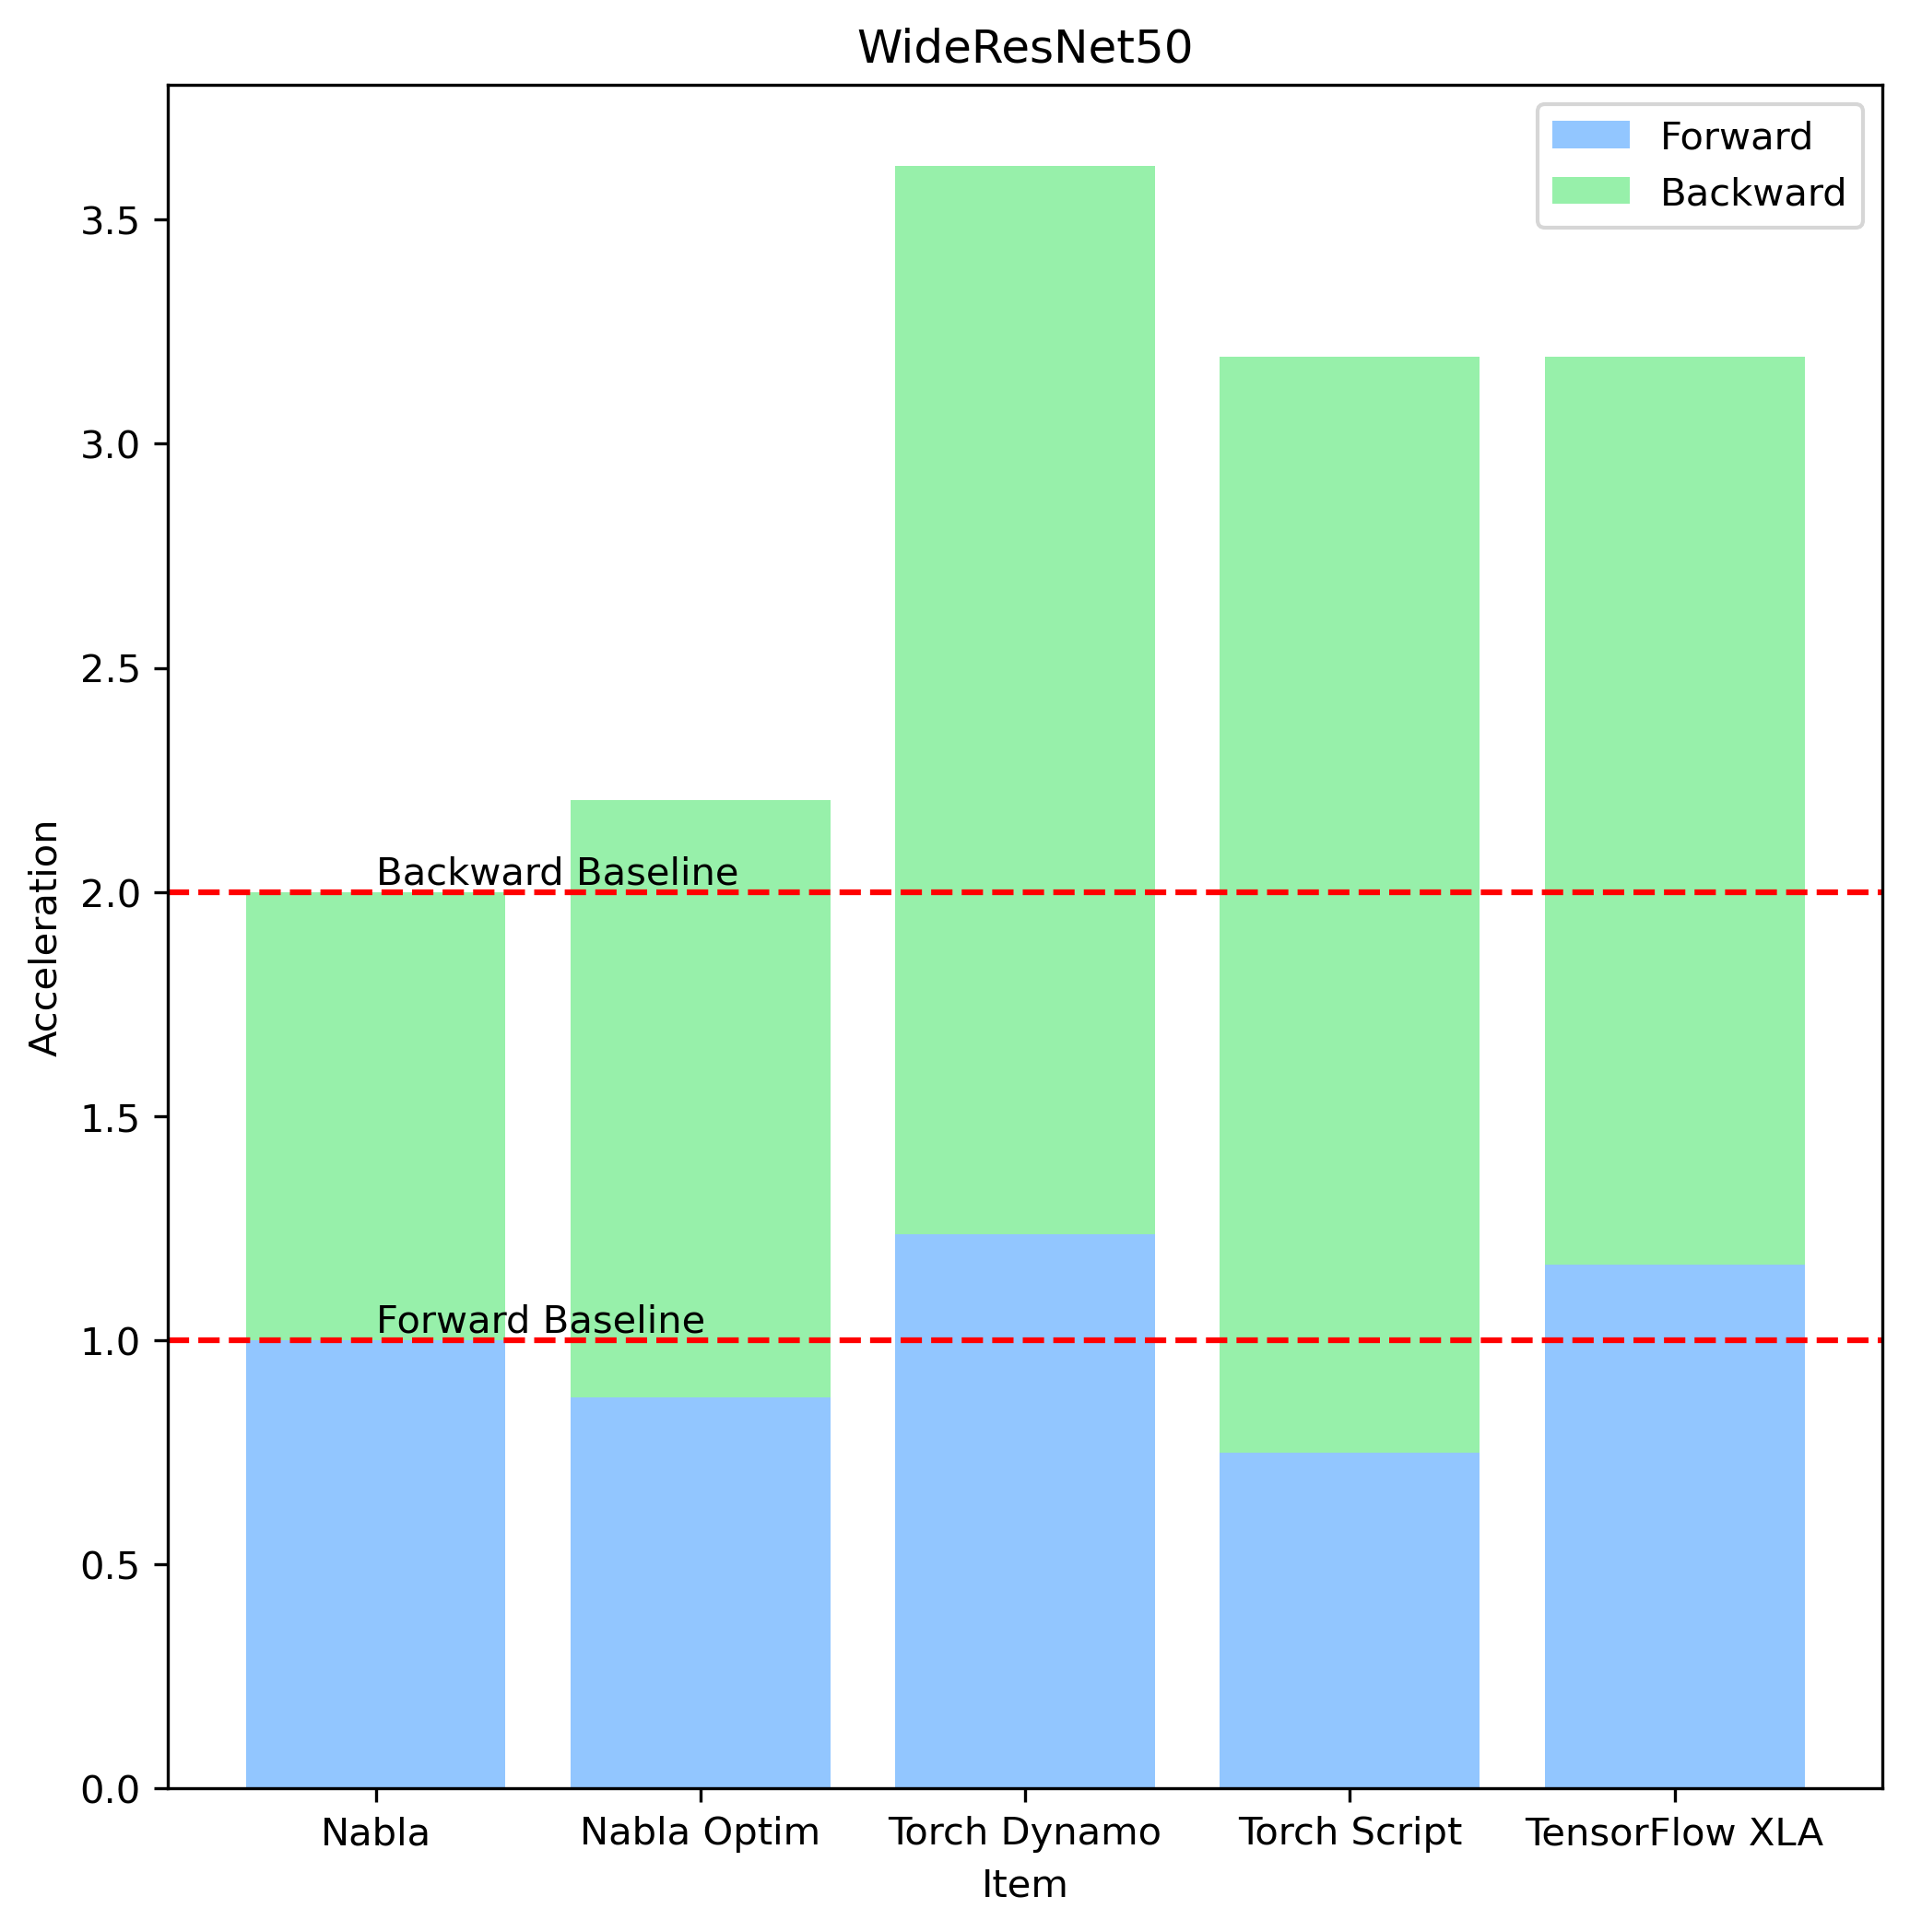

In [13]:
MODEL = "WideResNet50"
PATH = f"{ROOT}/wide_{MODEL.lower()[4:]}/"
torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

dfs = [torch2, torch1, tf]

for df in dfs:
    df.drop(
        columns="Unnamed: 0", inplace=True
    )
    df.drop(
        df[df["pass"] == "Full"].index, inplace=True
    )

torch2, torch1, tf = dfs

torch1.at[0, "item"] = "Torch Script"
torch1.at[3, "item"] = "Torch Script"

f_base, b_base, fo, bo = 0, 0, 0, 0
dfs = [torch2, torch1, tf]

for df in dfs:
    f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
    b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
    fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
    bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]

nabla_df = pd.DataFrame({
    "time": [f_base, b_base, fo, bo],
    "pass": ["Forward", "Backward"] * 2,
    "item": ["Nabla"] * 2 + ["Nabla Optim"] * 2
}, index=[0] * 4)
nabla_df

for df in dfs:
    nabla_df = pd.concat([
        nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
    ])
    
nabla_df.style.hide(axis="index")
f = nabla_df[nabla_df["pass"] == "Forward"]
b = nabla_df[nabla_df["pass"] == "Backward"]
f["acceleration"] = f_base / f["time"]
b["acceleration"] = b_base / b["time"]

items = ["Nabla", "Nabla Optim", "Torch Dynamo", "Torch Script", "TensorFlow XLA"]
plt.figure(dpi=300, figsize=(8, 8))

plt.bar(items, f["acceleration"], label="Forward")
plt.bar(items, b["acceleration"], label="Backward", bottom=f["acceleration"])

plt.xlabel("Item")
plt.ylabel("Acceleration")
plt.title(f"{MODEL}")
plt.legend()

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Forward Baseline", ha="left", va="bottom")
plt.axhline(2, color="red", linestyle="--", label="Baseline")
plt.text(0, 2, "Backward Baseline", ha="left", va="bottom")

print_time()

## WideResNet101

Model: WideResNet101
Forward:
  215.8682796203842
  237.50370331419012
  150.26573425158858
  256.75348724238575
  186.554303066805
Backward:
  740.8065863791853
  426.0576357599348
  394.7509331163019
  389.4776192400605
  470.5690930224955


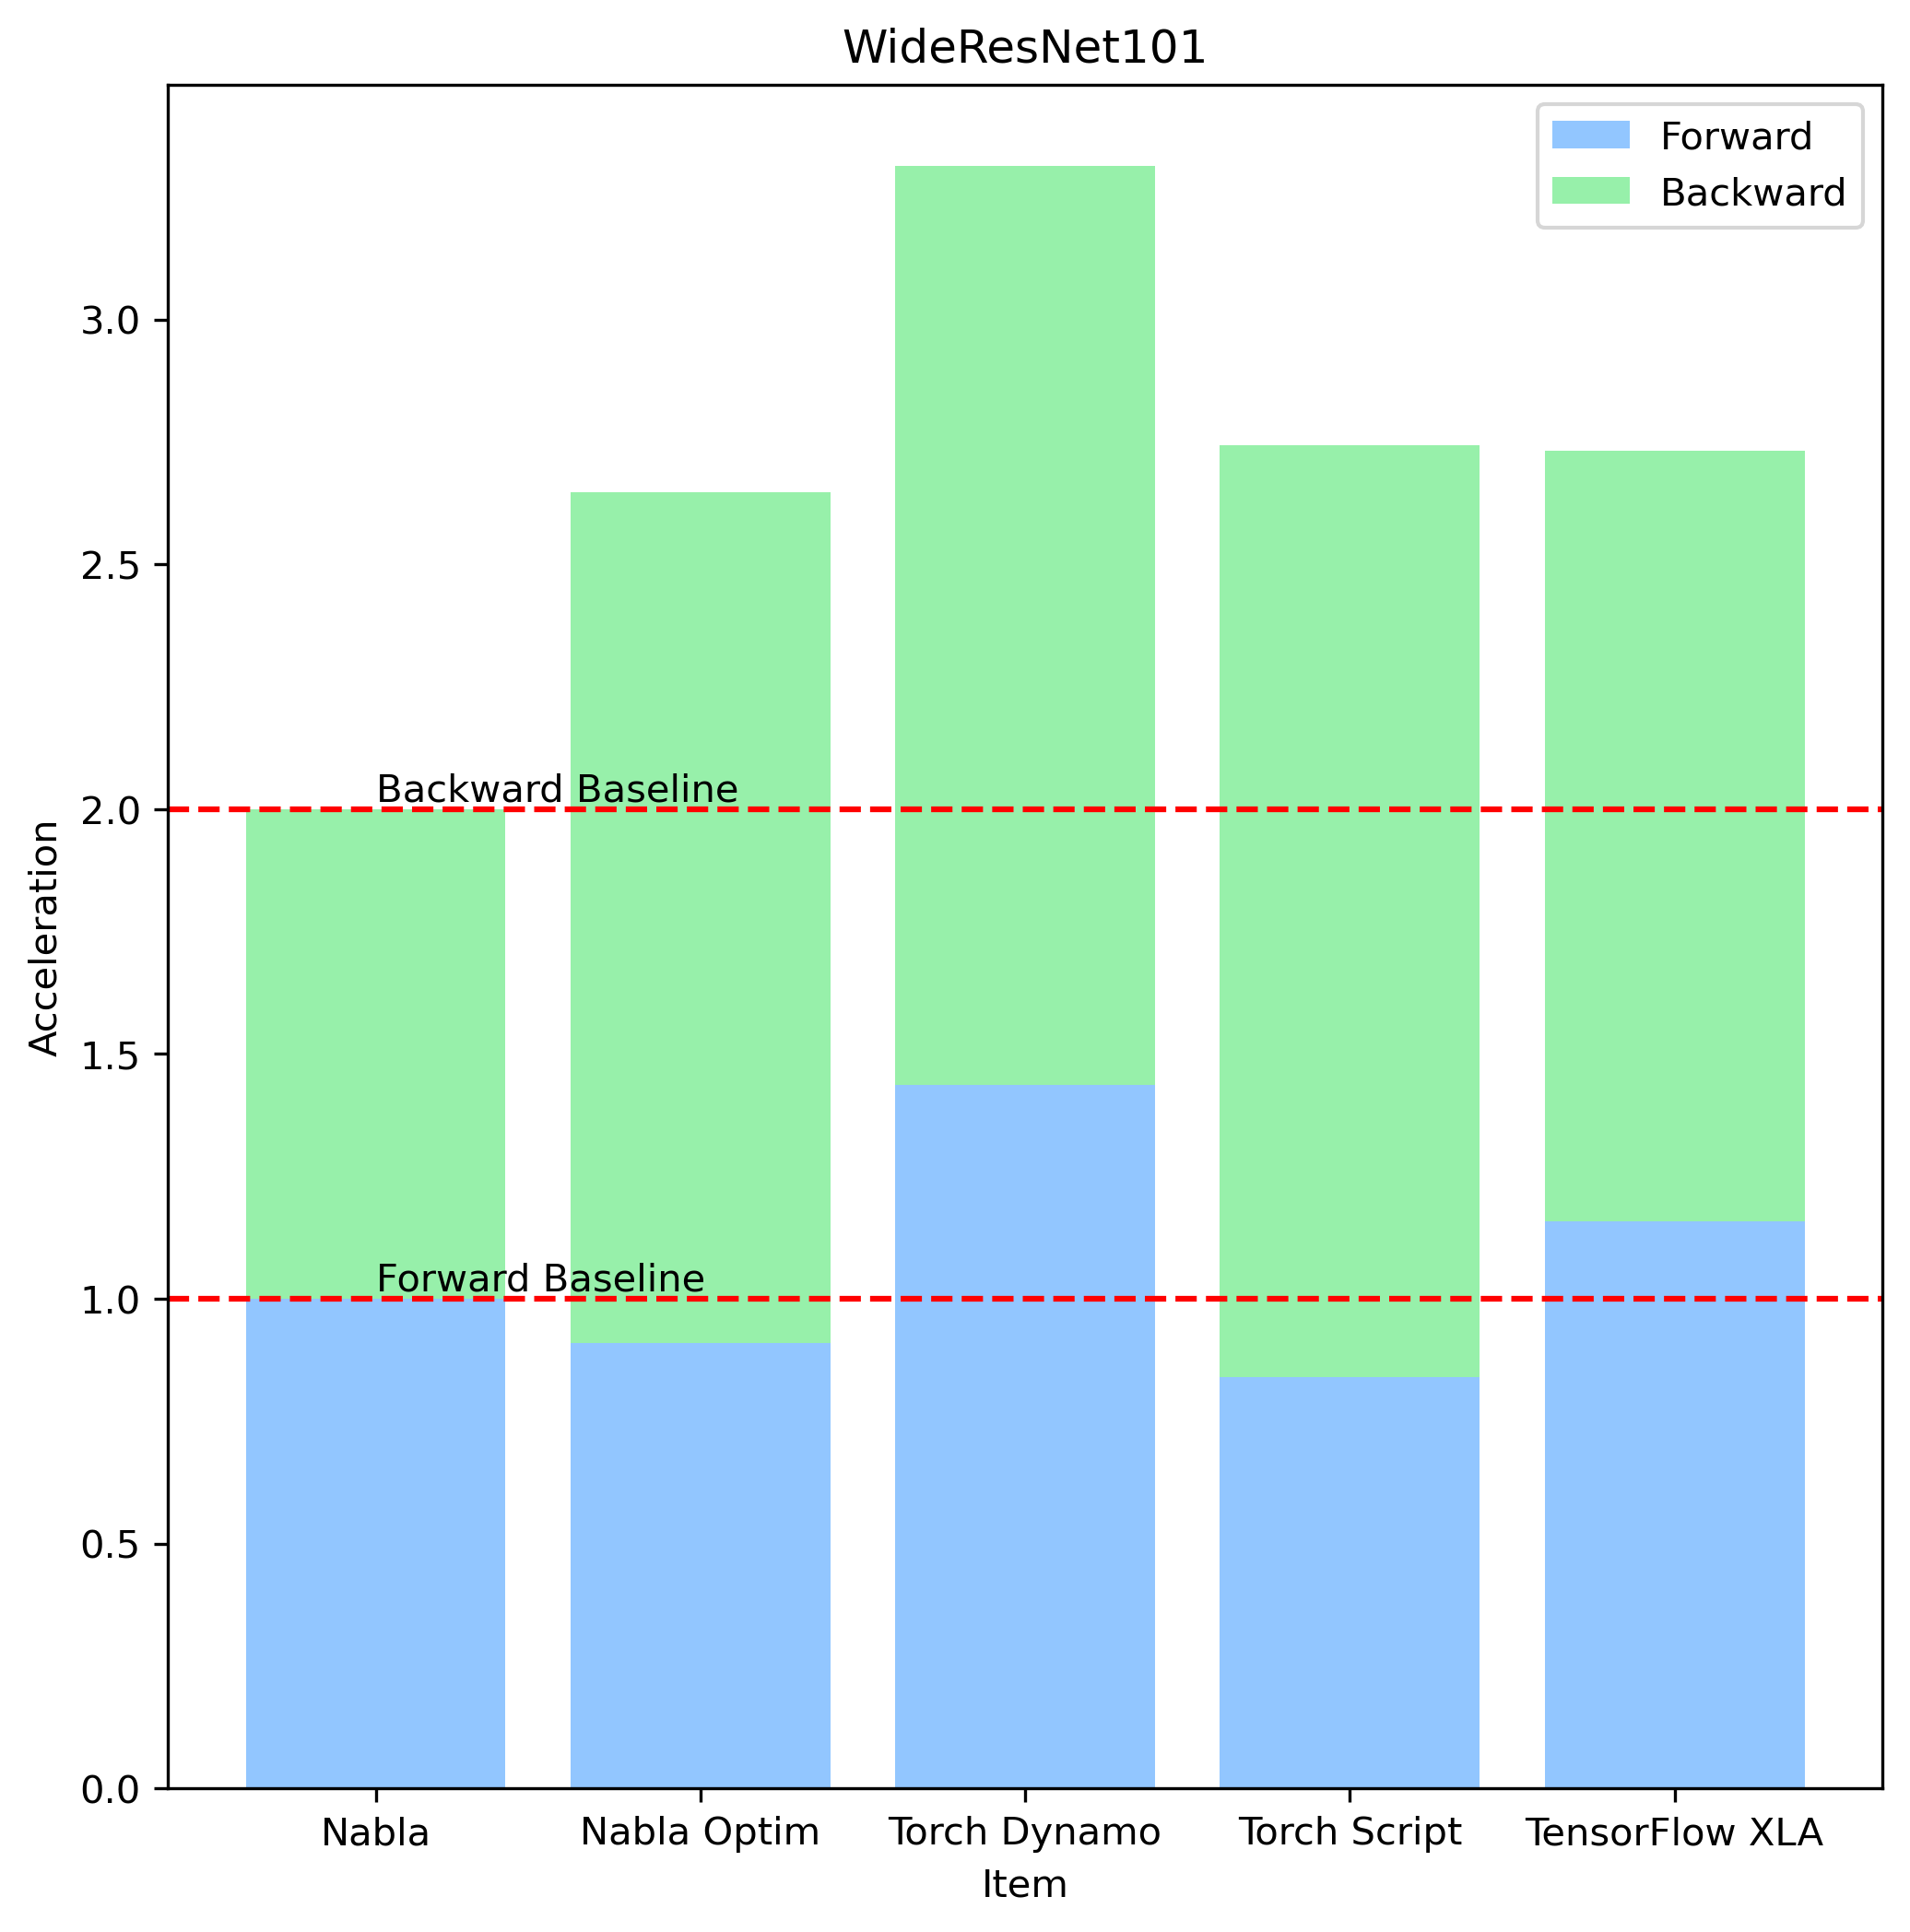

In [14]:
MODEL = "WideResNet101"
PATH = f"{ROOT}/wide_{MODEL.lower()[4:]}/"
torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

dfs = [torch2, torch1, tf]

for df in dfs:
    df.drop(
        columns="Unnamed: 0", inplace=True
    )
    df.drop(
        df[df["pass"] == "Full"].index, inplace=True
    )

torch2, torch1, tf = dfs

torch1.at[0, "item"] = "Torch Script"
torch1.at[3, "item"] = "Torch Script"

f_base, b_base, fo, bo = 0, 0, 0, 0
dfs = [torch2, torch1, tf]

for df in dfs:
    f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
    b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
    fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
    bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]

nabla_df = pd.DataFrame({
    "time": [f_base, b_base, fo, bo],
    "pass": ["Forward", "Backward"] * 2,
    "item": ["Nabla"] * 2 + ["Nabla Optim"] * 2
}, index=[0] * 4)
nabla_df

for df in dfs:
    nabla_df = pd.concat([
        nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
    ])
    
nabla_df.style.hide(axis="index")
f = nabla_df[nabla_df["pass"] == "Forward"]
b = nabla_df[nabla_df["pass"] == "Backward"]
f["acceleration"] = f_base / f["time"]
b["acceleration"] = b_base / b["time"]

items = ["Nabla", "Nabla Optim", "Torch Dynamo", "Torch Script", "TensorFlow XLA"]
plt.figure(dpi=300, figsize=(8, 8))

plt.bar(items, f["acceleration"], label="Forward")
plt.bar(items, b["acceleration"], label="Backward", bottom=f["acceleration"])

plt.xlabel("Item")
plt.ylabel("Acceleration")
plt.title(f"{MODEL}")
plt.legend()

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Forward Baseline", ha="left", va="bottom")
plt.axhline(2, color="red", linestyle="--", label="Baseline")
plt.text(0, 2, "Backward Baseline", ha="left", va="bottom")

print_time()

In [15]:
print_time()

Model: WideResNet101
Forward:
  215.8682796203842
  237.50370331419012
  150.26573425158858
  256.75348724238575
  186.554303066805
Backward:
  740.8065863791853
  426.0576357599348
  394.7509331163019
  389.4776192400605
  470.5690930224955
